## Abstract

本研究以 2024 年花蓮地震後之太魯閣沿海山區為研究區，利用 Sentinel-2 多光譜影像進行災後土地覆蓋分類與崩塌地驗證分析。研究首先以 K-means 進行非監督式分類，探索不同地物之光譜聚類特性，接著建立 ROI 訓練樣本並使用 Random Forest 進行監督式分類，將地表分為水體、森林、農地、裸地／崩塌地與建物等五類。模型內部驗證結果顯示整體分類精度高（Overall Accuracy = 98.9%，OOB Accuracy = 98.3%），顯示 Random Forest 能有效辨識主要土地覆蓋類型。此外，本研究進一步與農業部水土保持署（SWCB）崩塌 inventory 進行外部驗證，結果顯示崩塌類別與官方資料之空間重疊度偏低（IoU = 0.0032），反映 Sentinel-2 中解析度限制及裸露地物間之光譜混淆問題。最後，本研究結合大型語言模型（LLM）生成災後分析報告，探討 AI 輔助災害判讀與決策支援之潛力。

## Step 0. STAC API and Environment Preparation

本步驟先建立 Week 12 作業所需的 STAC API 工作環境。  
本作業延續 Week 8–10 的 Sentinel-2 串流流程，使用 Planetary Computer STAC API 搜尋秀林／太魯閣研究區的災後 Sentinel-2 L2A 影像。

研究區為 Xiulin / Taroko，範圍包含山區、崩塌地、河谷與太平洋近海，因此後續分類時可取得水體、森林、裸地／崩塌等多種地物樣本。

本步驟目的：
1. 讀取 `.env` 中的研究區與 STAC 設定。
2. 建立 output 與 data 資料夾。
3. 搜尋 2024/4/3 花蓮地震後的 Sentinel-2 L2A 影像。
4. 依雲量由嚴格到寬鬆逐步搜尋，選擇雲量最低的可用影像。
5. 準備進入 Task 1 的影像讀取與前處理。

In [1]:
# =============================================================================
# Step 0. STAC API and Environment Preparation
# =============================================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv

import pystac_client
import planetary_computer as pc
import stackstac

# -----------------------------------------------------------------------------
# 1. Load environment variables
# -----------------------------------------------------------------------------
load_dotenv()

STAC_ENDPOINT = os.getenv("STAC_ENDPOINT", "https://planetarycomputer.microsoft.com/api/stac/v1")
S2_COLLECTION = os.getenv("S2_COLLECTION", "sentinel-2-l2a")

BBOX_WEST = float(os.getenv("BBOX_WEST", 121.40))
BBOX_SOUTH = float(os.getenv("BBOX_SOUTH", 24.10))
BBOX_EAST = float(os.getenv("BBOX_EAST", 121.80))
BBOX_NORTH = float(os.getenv("BBOX_NORTH", 24.25))

TAROKO_BBOX = [BBOX_WEST, BBOX_SOUTH, BBOX_EAST, BBOX_NORTH]

TARGET_RESOLUTION = int(os.getenv("TARGET_RESOLUTION", 20))

OUTPUT_DIR = Path(os.getenv("OUTPUT_DIR", "output"))
DATA_DIR = Path(os.getenv("DATA_DIR", "data"))

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

print("STAC endpoint:", STAC_ENDPOINT)
print("Collection:", S2_COLLECTION)
print("Taroko BBOX:", TAROKO_BBOX)
print("Target resolution:", TARGET_RESOLUTION, "m")
print("Output directory:", OUTPUT_DIR)
print("Data directory:", DATA_DIR)

# -----------------------------------------------------------------------------
# 2. Define Sentinel-2 bands
# -----------------------------------------------------------------------------
BANDS = ["B02", "B03", "B04", "B08", "B11", "B12"]
BANDS_ALL = BANDS + ["SCL"]

band_description = {
    "B02": "Blue",
    "B03": "Green",
    "B04": "Red",
    "B08": "NIR",
    "B11": "SWIR1",
    "B12": "SWIR2",
    "SCL": "Scene Classification Layer"
}

print("\nBands used:")
for b in BANDS_ALL:
    print(f"  {b}: {band_description[b]}")

# -----------------------------------------------------------------------------
# 3. Connect to Planetary Computer STAC API
# -----------------------------------------------------------------------------
catalog = pystac_client.Client.open(
    STAC_ENDPOINT,
    modifier=pc.sign_inplace,
)

print("\nConnected to Planetary Computer STAC API.")

STAC endpoint: https://planetarycomputer.microsoft.com/api/stac/v1
Collection: sentinel-2-l2a
Taroko BBOX: [121.4, 24.1, 121.8, 24.25]
Target resolution: 20 m
Output directory: output
Data directory: data

Bands used:
  B02: Blue
  B03: Green
  B04: Red
  B08: NIR
  B11: SWIR1
  B12: SWIR2
  SCL: Scene Classification Layer

Connected to Planetary Computer STAC API.


In [2]:
# =============================================================================
# Step 0B. Progressive Search for Post-earthquake Sentinel-2 Imagery
# =============================================================================

search_configs = [
    ("2024-04-15/2024-05-31", 20, "Phase 1: 2 months post-quake, cloud cover < 20%"),
    ("2024-04-03/2024-08-31", 30, "Phase 2: 5 months post-quake, cloud cover < 30%"),
    ("2024-04-03/2024-12-31", 50, "Phase 3: full year post-quake, cloud cover < 50%"),
]

items = []

for dt_range, max_cc, desc in search_configs:
    print(f"\nTrying {desc}")
    
    search = catalog.search(
        collections=[S2_COLLECTION],
        bbox=TAROKO_BBOX,
        datetime=dt_range,
        query={"eo:cloud_cover": {"lt": max_cc}},
    )
    
    items = list(search.items())
    print(f"  Found {len(items)} scenes")
    
    if len(items) > 0:
        print("  Search successful. Stop progressive search.")
        break

if len(items) == 0:
    raise RuntimeError("No Sentinel-2 scenes found. Please relax cloud cover or date range.")

# Sort scenes by cloud cover
items_sorted = sorted(items, key=lambda x: x.properties.get("eo:cloud_cover", 999))
best_item = items_sorted[0]

print("\nSelected best scene:")
print("Item ID:", best_item.id)
print("Datetime:", best_item.datetime)
print("Cloud cover:", round(best_item.properties.get("eo:cloud_cover", np.nan), 2), "%")

# Show top 10 candidate scenes
scene_records = []

for item in items_sorted[:10]:
    scene_records.append({
        "item_id": item.id,
        "datetime": item.datetime,
        "cloud_cover": item.properties.get("eo:cloud_cover", np.nan),
    })

scene_df = pd.DataFrame(scene_records)
scene_df


Trying Phase 1: 2 months post-quake, cloud cover < 20%
  Found 0 scenes

Trying Phase 2: 5 months post-quake, cloud cover < 30%
  Found 10 scenes
  Search successful. Stop progressive search.

Selected best scene:
Item ID: S2A_MSIL2A_20240827T022531_R046_T51QUG_20240827T053853
Datetime: 2024-08-27 02:25:31.024000+00:00
Cloud cover: 8.36 %


,item_id,datetime,cloud_cover
0,S2A_MSIL2A_20240827T022531_R046_T51QUG_2024082...,2024-08-27 02:25:31.024000+00:00,8.358254
1,S2A_MSIL2A_20240718T022551_R046_T51QUG_2024071...,2024-07-18 02:25:51.024000+00:00,12.427387
2,S2A_MSIL2A_20240708T022551_R046_T51QUG_2024070...,2024-07-08 02:25:51.024000+00:00,12.923348
3,S2B_MSIL2A_20240404T022529_R046_T51QUG_2024040...,2024-04-04 02:25:29.024000+00:00,16.860856
4,S2B_MSIL2A_20240802T022529_R046_T51QUG_2024080...,2024-08-02 02:25:29.024000+00:00,20.888521
5,S2B_MSIL2A_20240822T022529_R046_T51QUG_2024082...,2024-08-22 02:25:29.024000+00:00,22.769178
6,S2B_MSIL2A_20240623T022539_R046_T51QUG_2024062...,2024-06-23 02:25:39.024000+00:00,24.691424
7,S2B_MSIL2A_20240713T022529_R046_T51QUG_2024071...,2024-07-13 02:25:29.024000+00:00,24.958557
8,S2B_MSIL2A_20240703T022539_R046_T51QUG_2024070...,2024-07-03 02:25:39.024000+00:00,25.826526
9,S2B_MSIL2A_20240812T022539_R046_T51QUG_2024081...,2024-08-12 02:25:39.024000+00:00,27.001759


### STAC Search Result

本作業依照指定的 progressive search 流程搜尋災後 Sentinel-2 L2A 影像。  
Phase 1（2024-04-15 至 2024-05-31，雲量 < 20%）未找到符合條件的影像，因此依照作業設定進入 Phase 2。  
Phase 2（2024-04-03 至 2024-08-31，雲量 < 30%）共找到 10 景影像，並依照 `eo:cloud_cover` 由低到高排序，選擇雲量最低的影像作為後續分類資料。

Selected scene: `S2A_MSIL2A_20240827T022531_R046_T51QUG_20240827T053853`  
Datetime: 2024-08-27  
Cloud cover: 8.36%

此影像雖距離 2024/4/3 地震約 5 個月，但符合老師設定的 Phase 2 搜尋條件，且雲量相對較低，適合作為後續 K-means 與 Random Forest 分類的基礎影像。

## Step 0C. Load Sentinel-2 Cube and Apply SCL Cloud Mask

本步驟使用前一步選出的 Sentinel-2 L2A 最佳影像，透過 `stackstac` 串流讀取 6 個反射率波段與 SCL 場景分類圖層。

處理流程：
1. 載入 B02、B03、B04、B08、B11、B12 與 SCL。
2. 將 Sentinel-2 surface reflectance 由整數值轉為 0–1 反射率。
3. 使用 SCL 建立有效像素遮罩，排除雲、雲影、雪與無效像素。
4. 產生 true color RGB 預覽圖，確認影像品質與研究區範圍。
5. 準備後續 Task 1 K-means 所需的 feature matrix。

Loaded image shape: (7, 852, 2041)
Bands: [np.str_('B02'), np.str_('B03'), np.str_('B04'), np.str_('B08'), np.str_('B11'), np.str_('B12'), np.str_('SCL')]
CRS: EPSG:32651
Resolution: 20 m
Total pixels: 1738932
Valid pixels after SCL + NaN mask: 1593880
Valid percentage: 91.66 %


,SCL_class,pixel_count,percentage
0,2,13505,0.776626
1,3,21859,1.257036
2,4,931924,53.591745
3,5,88696,5.100602
4,6,556493,32.001999
5,7,3263,0.187644
6,8,58918,3.388172
7,9,64274,3.696177


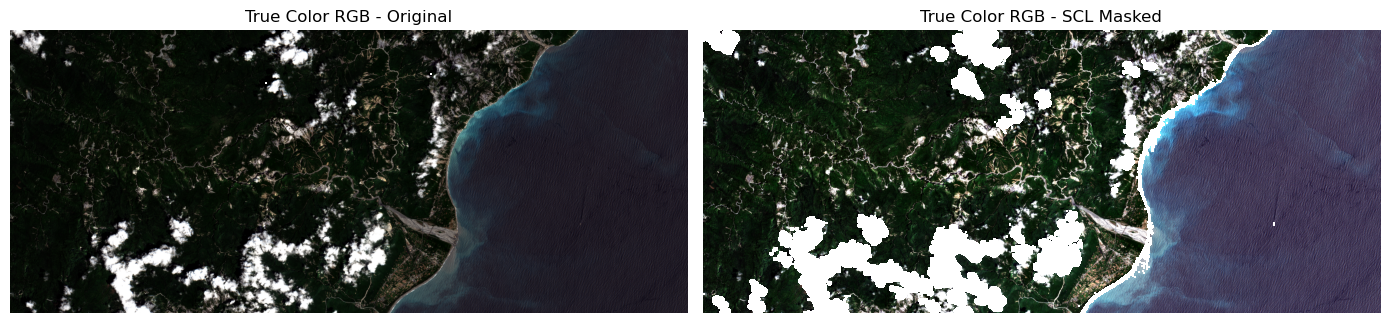

In [3]:
# =============================================================================
# Step 0C. Load Sentinel-2 Cube and Apply SCL Cloud Mask
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# 1. Load Sentinel-2 cube
# -----------------------------------------------------------------------------
cube = stackstac.stack(
    [best_item],
    assets=BANDS_ALL,
    bounds_latlon=TAROKO_BBOX,
    epsg=32651,
    resolution=20
)

img = cube.isel(time=0).compute()

print("Loaded image shape:", img.shape)
print("Bands:", list(img.band.values))
print("CRS: EPSG:32651")
print("Resolution: 20 m")

# -----------------------------------------------------------------------------
# 2. Separate reflectance bands and SCL
# -----------------------------------------------------------------------------
img_bands = img.sel(band=BANDS)
scl = img.sel(band="SCL")

# Sentinel-2 L2A reflectance scale factor
img_sr = img_bands / 10000.0

# -----------------------------------------------------------------------------
# 3. Build SCL valid mask
# -----------------------------------------------------------------------------
# SCL classes commonly treated as usable:
# 2 = dark area pixels
# 4 = vegetation
# 5 = bare soils
# 6 = water
# 7 = unclassified
# 11 = snow / ice
#
# For this homework, we keep clear land/water classes and exclude cloud/shadow.
# Because Taroko is not a snow-focused case, we exclude 11 to avoid snow confusion.

SCL_VALID_CLASSES = [2, 4, 5, 6, 7]

scl_values = scl.values
scl_valid = np.isin(scl_values, SCL_VALID_CLASSES)

# Also remove pixels with NaN in any reflectance band
X_temp = img_sr.values.reshape(len(BANDS), -1).T
nan_valid = ~np.isnan(X_temp).any(axis=1)
nan_valid_2d = nan_valid.reshape(scl_valid.shape)

valid_mask = scl_valid & nan_valid_2d

print("Total pixels:", valid_mask.size)
print("Valid pixels after SCL + NaN mask:", valid_mask.sum())
print("Valid percentage:", round(valid_mask.sum() / valid_mask.size * 100, 2), "%")

# -----------------------------------------------------------------------------
# 4. Show SCL distribution
# -----------------------------------------------------------------------------
unique_scl, counts_scl = np.unique(scl_values[~np.isnan(scl_values)], return_counts=True)

scl_df = pd.DataFrame({
    "SCL_class": unique_scl.astype(int),
    "pixel_count": counts_scl,
    "percentage": counts_scl / counts_scl.sum() * 100
})

display(scl_df)

# -----------------------------------------------------------------------------
# 5. Create true color RGB preview
# -----------------------------------------------------------------------------
# True color: Red = B04, Green = B03, Blue = B02
rgb = np.stack([
    img_sr.sel(band="B04").values,
    img_sr.sel(band="B03").values,
    img_sr.sel(band="B02").values
], axis=-1)

# Mask invalid pixels
rgb_masked = rgb.copy()
rgb_masked[~valid_mask] = np.nan

# Simple contrast stretch
def stretch_rgb(arr, p_low=2, p_high=98):
    out = arr.copy()
    for i in range(3):
        band = out[:, :, i]
        low, high = np.nanpercentile(band, [p_low, p_high])
        out[:, :, i] = np.clip((band - low) / (high - low), 0, 1)
    return out

rgb_stretched = stretch_rgb(rgb)
rgb_masked_stretched = stretch_rgb(rgb_masked)

# -----------------------------------------------------------------------------
# 6. Plot original and SCL-masked RGB
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(rgb_stretched)
axes[0].set_title("True Color RGB - Original")
axes[0].axis("off")

axes[1].imshow(rgb_masked_stretched)
axes[1].set_title("True Color RGB - SCL Masked")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### 影像品質檢查（Image Quality Check）

本研究成功載入 Sentinel-2 影像，共包含 7 個波段，其中包括 6 個反射率波段與 SCL（Scene Classification Layer）場景分類圖層。經 SCL 雲遮罩與 NaN 像素過濾後，共保留 1,593,880 個有效像素，約占研究區總像素的 91.66%。

SCL 統計結果顯示，研究區以植生類別為主，其次為水體，符合秀林／太魯閣地區以山區森林與太平洋海岸為主的地景特性。雲與高機率雲像素比例相對較低，且已於後續分析前完成遮罩處理。

True Color RGB 預覽圖顯示，雖然原始影像仍存在部分雲區，但經 SCL 遮罩後，大部分山區、河道、海岸與裸露地表仍保留完整資訊，因此此影像品質足以支援後續的 K-means 與 Random Forest 土地覆蓋分類分析。

# =============================================================================
# Task 1. K-means Unsupervised Classification
# =============================================================================

本任務使用 K-means 非監督式分類方法，對災後 Sentinel-2 多光譜影像進行土地覆蓋分群分析。

與後續 Random Forest 不同，K-means 不需要事先提供訓練資料，而是根據像素在多光譜特徵空間中的相似性，自動將像素分成 K 個群集。本研究設定 K=5，對應作業指定之五類主要地物：

1. 水體（Water）
2. 森林（Forest）
3. 農地（Cropland）
4. 裸地／崩塌地（Bare / Landslide）
5. 建物／都市（Built-up）

本步驟目的：
1. 建立多波段 feature matrix。
2. 使用 K-means 進行非監督分類。
3. 建立 K-means 分類圖。
4. 分析各 cluster 的平均光譜特徵。
5. 嘗試將 cluster 對應至實際土地覆蓋類別。

由於 K-means 僅依據光譜相似性分群，因此部分 cluster 可能同時混合多種地物，尤其在山區陰影、裸露地與都市區之間，可能出現光譜混淆。

In [4]:
# =============================================================================
# Task 1A. Build Feature Matrix
# =============================================================================

import numpy as np

# -----------------------------------------------------------------------------
# 1. Convert image cube to feature matrix
# -----------------------------------------------------------------------------
n_bands = len(BANDS)
h, w = valid_mask.shape

# shape: (bands, height, width) → (pixels, bands)
X = img_sr.values.reshape(n_bands, -1).T

print("Original feature matrix shape:", X.shape)

# -----------------------------------------------------------------------------
# 2. Remove invalid pixels using SCL mask
# -----------------------------------------------------------------------------
valid = valid_mask.reshape(-1)

X_valid = X[valid]

print("Valid feature matrix shape:", X_valid.shape)

# -----------------------------------------------------------------------------
# 3. Check reflectance statistics
# -----------------------------------------------------------------------------
print("\nReflectance statistics:")
print("Min:", np.nanmin(X_valid))
print("Max:", np.nanmax(X_valid))
print("Mean:", np.nanmean(X_valid))

Original feature matrix shape: (1738932, 6)
Valid feature matrix shape: (1593880, 6)

Reflectance statistics:
Min: 0.0905
Max: 1.512
Mean: 0.2147875958039501


In [5]:
# =============================================================================
# Task 1A-2. Feature Standardization
# =============================================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_valid_scaled = scaler.fit_transform(X_valid)

print("Feature standardization completed.")
print("Scaled mean:", X_valid_scaled.mean())
print("Scaled std:", X_valid_scaled.std())

Feature standardization completed.
Scaled mean: -2.601441981443258e-13
Scaled std: 0.9999999999999529


In [6]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

c:\Users\User\anaconda3\envs\gis-env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
C:\Users\User\AppData\Local\Temp\ipykernel_18220\2060064252.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_km = plt.cm.get_cmap("Set1", K)


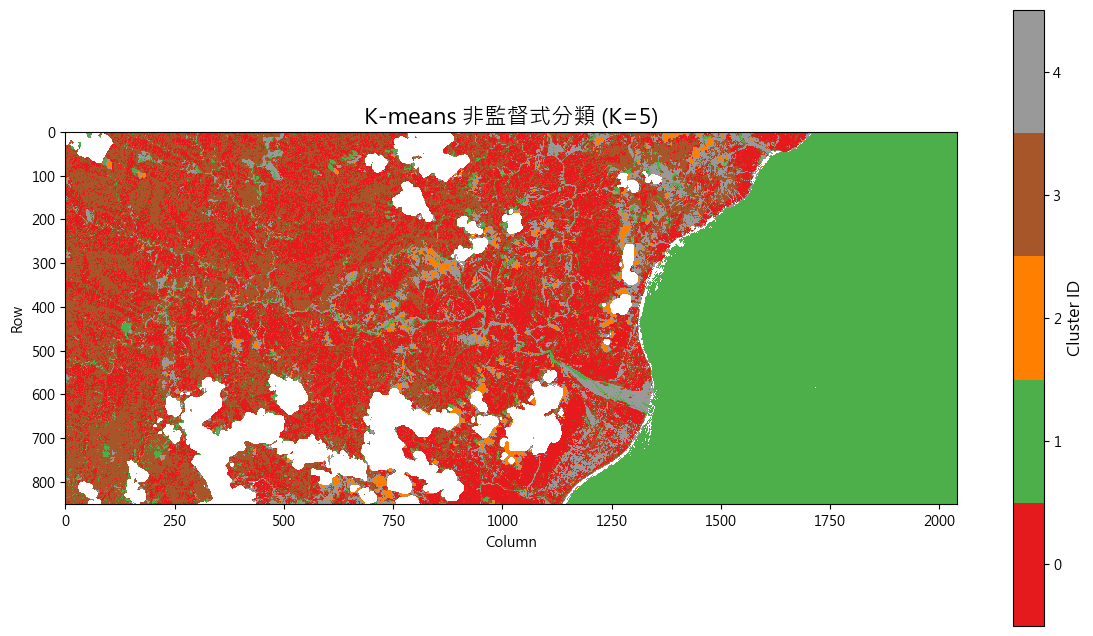

In [7]:
# =============================================================================
# Task 1B. K-means Clustering (K=5) — Follow Exercise Style
# =============================================================================

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

K = 5

kmeans = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=10,
    max_iter=300
)

labels = kmeans.fit_predict(X_valid)

label_map = np.full(h * w, np.nan)
label_map[valid] = labels
label_map = label_map.reshape(h, w)

fig, ax = plt.subplots(figsize=(12, 8))

cmap_km = plt.cm.get_cmap("Set1", K)

im = ax.imshow(
    label_map,
    cmap=cmap_km,
    vmin=-0.5,
    vmax=K - 0.5,
    interpolation="nearest"
)

cbar = plt.colorbar(im, ax=ax, ticks=range(K), shrink=0.8)
cbar.set_label("Cluster ID", fontsize=12)

ax.set_title("K-means 非監督式分類 (K=5)", fontsize=16)
ax.set_xlabel("Column")
ax.set_ylabel("Row")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "kmeans_classification.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### K-means 非監督式分類結果（K=5）

本研究使用 K-means 非監督式分類方法，將災後 Sentinel-2 多光譜影像分為 5 個 cluster，以探索不同地物在光譜空間中的自然分群結果。

分類結果顯示，海洋區域形成相對穩定且連續的大型 cluster，代表水體具有明顯且一致的光譜特徵；而山區則呈現較為複雜的空間分布，不同 cluster 交錯出現在森林、河道、裸露地與山區陰影區域。

此外，沿海沖積區與河口附近可觀察到與周圍山區不同的 cluster 分布，推測與裸露地、河道沉積物或崩塌地有關。

由於 K-means 僅依據光譜相似性進行分群，並未使用任何訓練資料，因此部分 cluster 可能同時包含多種實際地物。例如：
- 山區陰影可能與水體具有相似低反射特徵
- 裸露地與都市區可能同時具有較高 SWIR 反射率
- 森林內部也可能因坡向與陰影產生不同 cluster

因此，後續仍需透過光譜分析與人工判讀，進一步將各 cluster 對應至實際土地覆蓋類別。

## Task 1C. Cluster Spectral Analysis

本步驟計算每個 K-means cluster 的平均光譜特徵（Mean Spectral Signature），分析各 cluster 在不同 Sentinel-2 波段中的反射率差異。

分析波段包括：
- B02：Blue
- B03：Green
- B04：Red
- B08：Near Infrared（NIR）
- B11：SWIR1
- B12：SWIR2

透過比較各 cluster 的光譜曲線，可協助判斷其可能對應的土地覆蓋類別，例如：
- 水體通常具有低 NIR 與低 SWIR
- 森林通常具有高 NIR 與低 Red
- 裸露地／崩塌地通常具有較高 SWIR 反射率

本步驟同時建立 cluster 平均光譜表與光譜曲線圖，作為後續 cluster 標註與討論依據。

In [8]:
# =============================================================================
# Task 1C. Cluster Spectral Analysis
# =============================================================================

import pandas as pd
import numpy as np

band_names = ['B02', 'B03', 'B04', 'B08', 'B11', 'B12']

cluster_stats = []

print("各 Cluster 平均光譜特徵：\n")

for k in range(5):

    cluster_pixels = X_valid[labels == k]

    cluster_mean = cluster_pixels.mean(axis=0)

    print(
        f"Cluster {k}: "
        f"B02={cluster_mean[0]:.3f}, "
        f"B03={cluster_mean[1]:.3f}, "
        f"B04={cluster_mean[2]:.3f}, "
        f"B08={cluster_mean[3]:.3f}, "
        f"B11={cluster_mean[4]:.3f}, "
        f"B12={cluster_mean[5]:.3f}"
    )

    cluster_record = {
        "Cluster": k,
        "B02": round(cluster_mean[0], 3),
        "B03": round(cluster_mean[1], 3),
        "B04": round(cluster_mean[2], 3),
        "B08": round(cluster_mean[3], 3),
        "B11": round(cluster_mean[4], 3),
        "B12": round(cluster_mean[5], 3),
    }

    cluster_stats.append(cluster_record)

# -----------------------------------------------------------------------------
# Convert to DataFrame
# -----------------------------------------------------------------------------
cluster_df = pd.DataFrame(cluster_stats)

display(cluster_df)

各 Cluster 平均光譜特徵：

Cluster 0: B02=0.128, B03=0.160, B04=0.131, B08=0.530, B11=0.311, B12=0.192
Cluster 1: B02=0.190, B03=0.182, B04=0.171, B08=0.169, B11=0.168, B12=0.157
Cluster 2: B02=0.428, B03=0.438, B04=0.434, B08=0.528, B11=0.517, B12=0.440
Cluster 3: B02=0.125, B03=0.148, B04=0.129, B08=0.412, B11=0.277, B12=0.181
Cluster 4: B02=0.238, B03=0.259, B04=0.256, B08=0.368, B11=0.358, B12=0.289


,Cluster,B02,B03,B04,B08,B11,B12
0,0,0.128,0.160,0.131,0.530,0.311,0.192
1,1,0.190,0.182,0.171,0.169,0.168,0.157
2,2,0.428,0.438,0.434,0.528,0.517,0.440
3,3,0.125,0.148,0.129,0.412,0.277,0.181
4,4,0.238,0.259,0.256,0.368,0.358,0.289


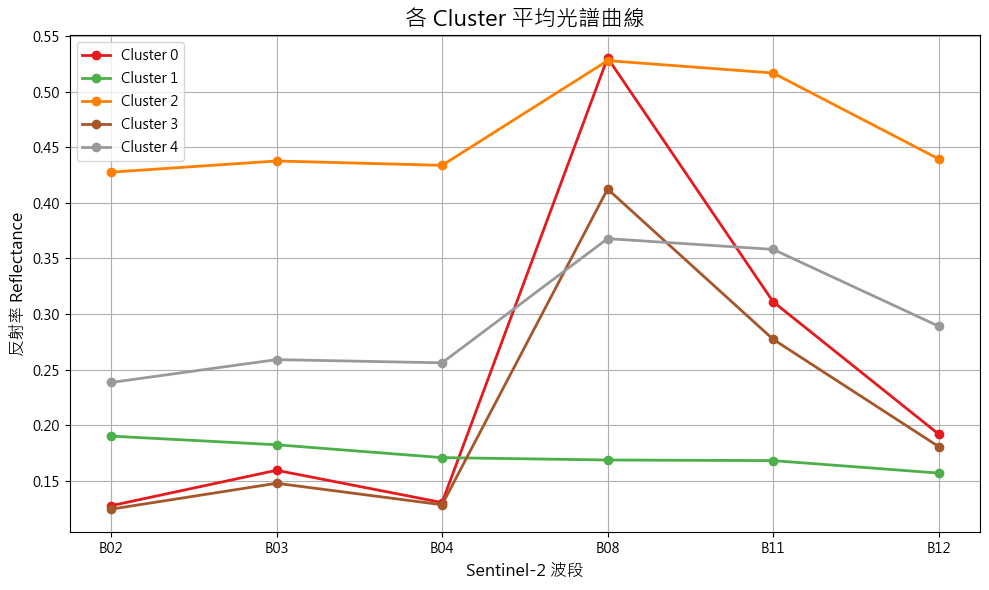

Saved:
output\kmeans_spectral_profiles.png


In [9]:
# =============================================================================
# Task 1D. Spectral Signature Plot
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 6))

# 使用與 K-means 分類圖一致的 Set1 色盤
colors_spec = plt.cm.Set1(np.linspace(0, 1, 5))

# -----------------------------------------------------------------------------
# Plot mean spectral signature for each cluster
# -----------------------------------------------------------------------------
for k in range(5):

    cluster_mean = X_valid[labels == k].mean(axis=0)

    ax.plot(
        band_names,
        cluster_mean,
        marker='o',
        linewidth=2,
        color=colors_spec[k],
        label=f'Cluster {k}'
    )

# -----------------------------------------------------------------------------
# Figure settings
# -----------------------------------------------------------------------------
ax.set_title("各 Cluster 平均光譜曲線", fontsize=16)

ax.set_xlabel("Sentinel-2 波段", fontsize=12)

ax.set_ylabel("反射率 Reflectance", fontsize=12)

ax.grid(True)

ax.legend()

# -----------------------------------------------------------------------------
# Save deliverable
# -----------------------------------------------------------------------------
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "kmeans_spectral_profiles.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(OUTPUT_DIR / "kmeans_spectral_profiles.png")

### Cluster 光譜判讀與土地覆蓋標註

根據各 cluster 的平均光譜特徵與光譜曲線，可將 K-means 分群結果初步對應至不同土地覆蓋類別。

其中：
- 水體具有低 NIR 與低 SWIR 特徵
- 森林具有高 NIR 與低 Red 特徵
- 裸地／崩塌地具有較高 SWIR 反射率
- 都市與混合地表則呈現中高反射率與較平坦光譜曲線

由於秀林／太魯閣研究區以山區地形為主，因此山區陰影、坡向差異與混合像素會導致部分 cluster 難以完全對應單一地物。例如森林可能因陰影而被分成不同 cluster，而河道沉積區與都市區也可能具有相似的 SWIR 特徵。

In [10]:
# =============================================================================
# Task 1E. Manual Cluster Labeling
# =============================================================================

cluster_df["Land_Cover_Label"] = [
    "Forest",
    "Water",
    "Bare / Landslide",
    "Shadowed Forest",
    "Built-up / Mixed Surface"
]

display(cluster_df)

# -----------------------------------------------------------------------------
# Save cluster spectral table
# -----------------------------------------------------------------------------

cluster_df.to_csv(
    OUTPUT_DIR / "kmeans_cluster_spectra.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved:")
print(OUTPUT_DIR / "kmeans_cluster_spectra.csv")

,Cluster,B02,B03,B04,B08,B11,B12,Land_Cover_Label
0,0,0.128,0.160,0.131,0.530,0.311,0.192,Forest
1,1,0.190,0.182,0.171,0.169,0.168,0.157,Water
2,2,0.428,0.438,0.434,0.528,0.517,0.440,Bare / Landslide
3,3,0.125,0.148,0.129,0.412,0.277,0.181,Shadowed Forest
4,4,0.238,0.259,0.256,0.368,0.358,0.289,Built-up / Mixed Surface


Saved:
output\kmeans_cluster_spectra.csv


In [11]:
# =============================================================================
# Task 1E. Manual Cluster Interpretation
# =============================================================================

cluster_labels_df = pd.DataFrame({
    "Cluster_ID": [0, 1, 2, 3, 4],

    "Suggested_Label": [
        "Forest",
        "Water",
        "Bare soil / urban mix",
        "Dense vegetation shadow",
        "Agriculture / mixed vegetation"
    ],

    "Interpretation": [
        "High NIR reflectance indicates healthy vegetation.",
        "Low NIR and SWIR reflectance consistent with water.",
        "High reflectance across visible and SWIR bands.",
        "Vegetation-like spectrum but darker overall due to terrain shadow.",
        "Intermediate vegetation reflectance mixed with soil background."
    ]
})

display(cluster_labels_df)

cluster_labels_df.to_csv(
    OUTPUT_DIR / "kmeans_cluster_labels.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved:")
print(OUTPUT_DIR / "kmeans_cluster_labels.csv")

,Cluster_ID,Suggested_Label,Interpretation
0,0,Forest,High NIR reflectance indicates healthy vegetat...
1,1,Water,Low NIR and SWIR reflectance consistent with w...
2,2,Bare soil / urban mix,High reflectance across visible and SWIR bands.
3,3,Dense vegetation shadow,Vegetation-like spectrum but darker overall du...
4,4,Agriculture / mixed vegetation,Intermediate vegetation reflectance mixed with...


Saved:
output\kmeans_cluster_labels.csv


### Task 1 Discussion

本研究之 K-means 分類結果顯示，水體與裸地／崩塌地具有相對明顯的光譜特徵，因此較容易形成穩定且可辨識的 cluster。尤其水體在 NIR 與 SWIR 波段具有明顯低反射率，而裸露地與崩塌地則具有較高 SWIR 反射率，因此容易與其他地物區分。

相較之下，森林類別較難完全對應單一 cluster。本研究中森林被分成多個 cluster，推測與山區陰影、坡向差異與植生濕度有關。由於太魯閣地區地形起伏劇烈，不同坡面接受日照條件差異大，即使為相同植生類型，也可能具有不同反射率特徵。

此外，都市區、河道沉積區與部分裸露地之間亦存在光譜混淆，顯示 K-means 僅依據光譜距離進行分群時，仍可能受到混合像素與地形效應影響。因此後續仍需透過監督式分類（Random Forest）與訓練樣本進一步提升分類精度。

## Task 2A. KMZ ROI Training Sample Parsing

本步驟使用 Google Earth 繪製的 ROI polygon 作為 Random Forest 監督式分類的訓練樣本。  
ROI 會先從 KMZ 檔案中解析出各類別 polygon，再轉換為影像格網上的訓練像素。

本研究採用五類土地覆蓋類別：

1. Water：水體
2. Forest：森林
3. Agriculture / Cropland：農地
4. Bare / Landslide：裸地／崩塌地
5. Built-up：建物／都市

KMZ 中的 polygon 名稱不一定要完全相同，但需包含可辨識的關鍵字，例如：
- 水體、Water
- 森林、Forest
- 農地、Agriculture、Cropland
- 裸地、崩塌、Bare、Landslide
- 建物、Built-up

本步驟會自動解析 KMZ、建立 ROI raster，並提取各類別訓練像素。

In [12]:
# =============================================================================
# Task 2 Preparation. Prepare Variables for ROI Parsing
# =============================================================================

import os
import zipfile
import tempfile
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import pyproj

from pathlib import Path
from shapely.geometry import Polygon
from rasterio.features import rasterize
from rasterio.transform import from_bounds
from matplotlib.patches import Patch

# -----------------------------------------------------------------------------
# 1. Prepare image array
# -----------------------------------------------------------------------------
# img_sr: xarray DataArray, shape = (bands, rows, cols)
# 只包含 B02, B03, B04, B08, B11, B12 六個反射率波段
img = img_sr.values

n_bands, n_rows, n_cols = img.shape

# -----------------------------------------------------------------------------
# 2. Build transform matching current image grid
# -----------------------------------------------------------------------------
# 注意：這裡依照 HW.md 後續 SWCB rasterize 的邏輯，
# 使用 TAROKO_BBOX 與目前影像尺寸建立 raster transform。
img_transform = from_bounds(
    TAROKO_BBOX[0],
    TAROKO_BBOX[1],
    TAROKO_BBOX[2],
    TAROKO_BBOX[3],
    n_cols,
    n_rows
)

BAND_NAMES = ["Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2"]

print("Prepared Task 2 variables:")
print("img shape:", img.shape)
print("n_bands:", n_bands)
print("n_rows:", n_rows)
print("n_cols:", n_cols)
print("BAND_NAMES:", BAND_NAMES)

Prepared Task 2 variables:
img shape: (6, 852, 2041)
n_bands: 6
n_rows: 852
n_cols: 2041
BAND_NAMES: ['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2']


使用 KMZ 檔案：
data\W12_6.kmz

--- 解析 KMZ ---
  ✓ 森林 → Forest / 森林
  ✓ 森林 → Forest / 森林
  ✓ 森林 → Forest / 森林
  ✓ 裸露地 → Bare/Landslide / 裸地/崩塌
  ✓ 裸露地 → Bare/Landslide / 裸地/崩塌
  ✓ 裸露地 → Bare/Landslide / 裸地/崩塌
  ✓ 建物 → Built-up / 建物
  ✓ 建物 → Built-up / 建物
  ✓ 建物 → Built-up / 建物
  ✓ 農地 → Agriculture / 農地
  ✓ 農地 → Agriculture / 農地
  ✓ 農地 → Agriculture / 農地
  ✓ 建物 → Built-up / 建物
  ✓ 建物 → Built-up / 建物
  ✓ 建物 → Built-up / 建物
  ✓ 建物 → Built-up / 建物
  ✓ 建物 → Built-up / 建物
  ✓ 水體 → Water / 水體
  ✓ 水體 → Water / 水體
  ✓ 建物 → Built-up / 建物
  ✓ 建物 → Built-up / 建物
  ✓ 建物 → Built-up / 建物

ROI raster 建立完成。
ROI pixels before SCL filtering: 7106

=== 訓練樣本統計 ===
總訓練像素數: 7,007

  Class 0 (           Water / 水體):  3,477 pixels, 2 個多邊形  ✅ 充足
  Class 1 (          Forest / 森林):  2,812 pixels, 3 個多邊形  ✅ 充足
  Class 2 (     Agriculture / 農地):    255 pixels, 3 個多邊形  ✅ 充足
  Class 3 (  Bare/Landslide / 裸地/崩塌):    285 pixels, 3 個多邊形  ✅ 充足
  Class 4 (        Built-up / 建物):    178 pixels, 11 個多邊形  ✅ 充足


,Class_ID,Class_Name,Class_Name_ZH,Pixel_Count,Polygon_Count,Status
0,0,Water,水體,3477,2,✅ 充足
1,1,Forest,森林,2812,3,✅ 充足
2,2,Agriculture,農地,255,3,✅ 充足
3,3,Bare/Landslide,裸地/崩塌,285,3,✅ 充足
4,4,Built-up,建物,178,11,✅ 充足



Saved:
output\roi_training_sample_counts.csv


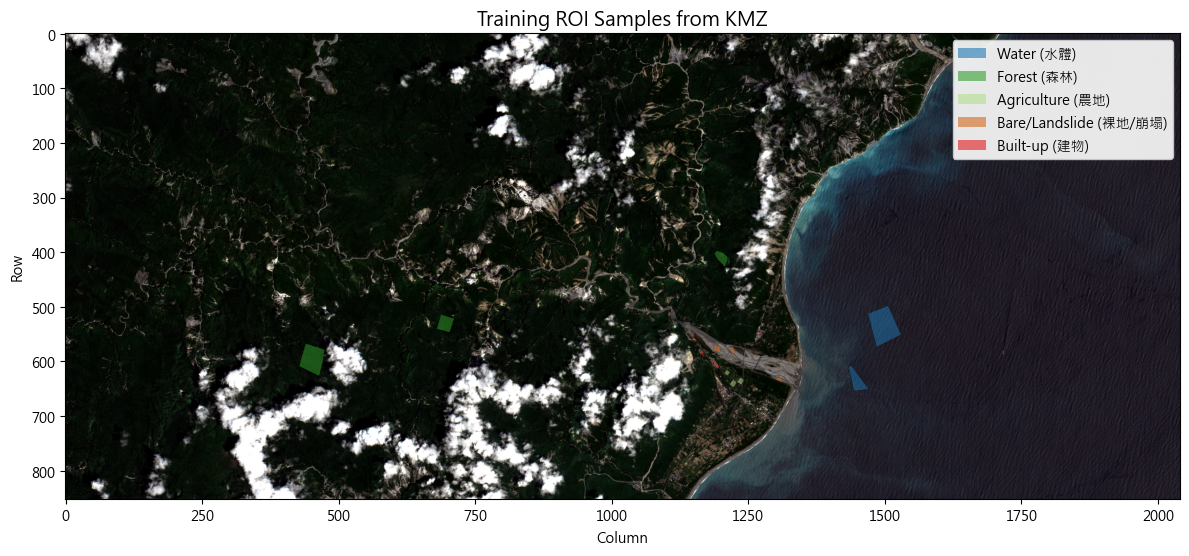

Saved:
output\roi_training_samples.png

檢查你的 ROI 是否合理：
  - 水體 ROI 是否確實在海面或河流上？
  - 森林 ROI 是否在山坡密林區？
  - 農地是否避免混入裸地或建物？
  - 裸地／崩塌 ROI 是否避開河水與雲影？
  - 建物 ROI 是否確實落在聚落或道路建成區？
  - 每類是否至少有 50–100 個像素？


In [13]:
# =============================================================================
# [S12] Load KMZ + Parse ROI Training Samples
# =============================================================================

# -----------------------------------------------------------------------------
# 1. Class definitions
# -----------------------------------------------------------------------------
CLASS_NAMES = ["Water", "Forest", "Agriculture", "Bare/Landslide", "Built-up"]
CLASS_NAMES_ZH = ["水體", "森林", "農地", "裸地/崩塌", "建物"]
N_CLASSES = len(CLASS_NAMES)

# KMZ polygon name → class ID
# Google Earth 中 polygon 名稱只要包含以下任一關鍵字即可
name_to_class = {
    "水體": 0, "水": 0, "Water": 0, "water": 0,
    "森林": 1, "林": 1, "Forest": 1, "forest": 1,
    "農地": 2, "農": 2, "Agriculture": 2, "agriculture": 2, "Cropland": 2, "cropland": 2,
    "裸露地": 3, "裸地": 3, "崩塌": 3, "裸": 3, "Bare": 3, "bare": 3, "Landslide": 3, "landslide": 3,
    "建物": 4, "建": 4, "Built": 4, "built": 4, "Built-up": 4, "built-up": 4,
}

# -----------------------------------------------------------------------------
# 2. Set KMZ path
# -----------------------------------------------------------------------------
kmz_filename = DATA_DIR / "W12_6.kmz"

if not kmz_filename.exists():
    raise FileNotFoundError(
        f"找不到 KMZ 檔案：{kmz_filename}\n"
        "請先將 Google Earth 匯出的 KMZ 檔放到 data/ 資料夾，"
        "或修改 kmz_filename 的檔名。"
    )

print("使用 KMZ 檔案：")
print(kmz_filename)

# -----------------------------------------------------------------------------
# 3. Helper function: RGB preview
# -----------------------------------------------------------------------------
def make_rgb(img_array, bands=[2, 1, 0], p_low=2, p_high=98):
    """
    建立 RGB 顯示影像。
    img_array shape: (bands, rows, cols)
    bands: 預設 [2,1,0] = B04, B03, B02 true color
    """
    rgb = np.stack([img_array[b] for b in bands], axis=-1)

    out = rgb.copy()

    for i in range(3):
        band = out[:, :, i]
        low, high = np.nanpercentile(band, [p_low, p_high])
        out[:, :, i] = np.clip((band - low) / (high - low), 0, 1)

    out[np.isnan(out)] = 0

    return out

# -----------------------------------------------------------------------------
# 4. Parse KMZ
# -----------------------------------------------------------------------------
def parse_kmz(filename):
    """
    解析 KMZ 檔案，回傳：
    polygons_by_class = {class_id: [Polygon, Polygon, ...]}
    """
    polygons_by_class = {i: [] for i in range(N_CLASSES)}

    with zipfile.ZipFile(filename, "r") as z:
        kml_candidates = [n for n in z.namelist() if n.lower().endswith(".kml")]

        if len(kml_candidates) == 0:
            raise FileNotFoundError("KMZ 中找不到 KML 檔案。")

        kml_name = kml_candidates[0]

        with z.open(kml_name) as f:
            tree = ET.parse(f)

    ns = {"kml": "http://www.opengis.net/kml/2.2"}

    for pm in tree.findall(".//kml:Placemark", ns):

        name_elem = pm.find("kml:name", ns)
        coords_elem = pm.find(".//kml:coordinates", ns)

        if name_elem is None or coords_elem is None:
            continue

        pm_name = name_elem.text.strip()

        # 比對名稱 → 類別 ID
        cls_id = None

        for keyword, cid in name_to_class.items():
            if keyword in pm_name:
                cls_id = cid
                break

        if cls_id is None:
            print(f"  ⚠️ 無法辨識類別：'{pm_name}'，已跳過")
            continue

        # 解析座標
        coords_text = coords_elem.text.strip()
        points = []

        for c in coords_text.split():
            parts = c.split(",")

            if len(parts) >= 2:
                lon = float(parts[0])
                lat = float(parts[1])
                points.append((lon, lat))

        if len(points) >= 3:
            poly = Polygon(points)

            if poly.is_valid and poly.area > 0:
                polygons_by_class[cls_id].append(poly)
                print(f"  ✓ {pm_name} → {CLASS_NAMES[cls_id]} / {CLASS_NAMES_ZH[cls_id]}")

    return polygons_by_class

print("\n--- 解析 KMZ ---")
polygons_by_class = parse_kmz(kmz_filename)

# -----------------------------------------------------------------------------
# 5. Convert polygons to raster grid
# -----------------------------------------------------------------------------
shapes_for_rasterize = []

for cls_id, poly_list in polygons_by_class.items():

    for poly in poly_list:

        if poly.is_valid and poly.area > 0:
            shapes_for_rasterize.append((poly, cls_id))

if len(shapes_for_rasterize) == 0:
    raise ValueError("沒有任何可用的 ROI polygon。請確認 KMZ polygon 名稱與類別關鍵字。")

roi_raster = rasterize(
    shapes_for_rasterize,
    out_shape=(n_rows, n_cols),
    transform=img_transform,
    fill=-1,
    dtype=np.int16,
    all_touched=True,
)

print("\nROI raster 建立完成。")
print("ROI pixels before SCL filtering:", int(np.sum(roi_raster >= 0)))

# -----------------------------------------------------------------------------
# 6. Extract training pixels
# -----------------------------------------------------------------------------
X_train_list = []
y_train_list = []

for cls_id in range(N_CLASSES):

    # 只取 ROI 內且通過 SCL / NaN mask 的像素
    cls_mask = (roi_raster == cls_id) & valid_mask

    cls_pixels = img[:, cls_mask].T

    valid_rows = ~np.any(np.isnan(cls_pixels), axis=1)
    cls_valid = cls_pixels[valid_rows]

    if len(cls_valid) > 0:
        X_train_list.append(cls_valid)
        y_train_list.append(np.full(len(cls_valid), cls_id))

if len(X_train_list) == 0:
    raise ValueError("沒有提取到任何有效訓練像素。請檢查 ROI 是否落在影像範圍內，或是否被雲遮罩排除。")

X_roi = np.vstack(X_train_list)
y_roi = np.concatenate(y_train_list)

# -----------------------------------------------------------------------------
# 7. Training sample statistics
# -----------------------------------------------------------------------------
print("\n=== 訓練樣本統計 ===")
print(f"總訓練像素數: {len(y_roi):,}\n")

roi_sample_records = []

for cls_id in range(N_CLASSES):

    count = int(np.sum(y_roi == cls_id))
    n_poly = len(polygons_by_class[cls_id])

    if count >= 100:
        status = "✅ 充足"
    elif count >= 50:
        status = "✅ 合格"
    elif count >= 30:
        status = "🔶 偏少"
    else:
        status = "⚠️ 不足，建議增加 ROI"

    print(
        f"  Class {cls_id} ({CLASS_NAMES[cls_id]:>16s} / "
        f"{CLASS_NAMES_ZH[cls_id]}): {count:>6,} pixels, "
        f"{n_poly} 個多邊形  {status}"
    )

    roi_sample_records.append({
        "Class_ID": cls_id,
        "Class_Name": CLASS_NAMES[cls_id],
        "Class_Name_ZH": CLASS_NAMES_ZH[cls_id],
        "Pixel_Count": count,
        "Polygon_Count": n_poly,
        "Status": status
    })

roi_sample_df = pd.DataFrame(roi_sample_records)

display(roi_sample_df)

roi_sample_df.to_csv(
    OUTPUT_DIR / "roi_training_sample_counts.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved:")
print(OUTPUT_DIR / "roi_training_sample_counts.csv")

# -----------------------------------------------------------------------------
# 8. Visualize ROI overlay
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8))

ax.imshow(make_rgb(img, [2, 1, 0]))

roi_colors_vis = [
    "#1f78b4",  # Water
    "#33a02c",  # Forest
    "#b2df8a",  # Agriculture
    "#d2691e",  # Bare/Landslide
    "#e31a1c",  # Built-up
]

for cls_id in range(N_CLASSES):

    mask = (roi_raster == cls_id)

    if np.any(mask):
        overlay = np.zeros((*mask.shape, 4))
        color_rgba = mcolors.to_rgba(roi_colors_vis[cls_id], alpha=0.5)
        overlay[mask] = color_rgba
        ax.imshow(overlay)

legend_roi = [
    Patch(
        facecolor=roi_colors_vis[i],
        alpha=0.6,
        label=f"{CLASS_NAMES[i]} ({CLASS_NAMES_ZH[i]})"
    )
    for i in range(N_CLASSES)
]

ax.legend(
    handles=legend_roi,
    loc="upper right",
    fontsize=10,
    framealpha=0.9
)

ax.set_title("Training ROI Samples from KMZ", fontsize=14)
ax.set_xlabel("Column")
ax.set_ylabel("Row")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "roi_training_samples.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(OUTPUT_DIR / "roi_training_samples.png")

print("\n檢查你的 ROI 是否合理：")
print("  - 水體 ROI 是否確實在海面或河流上？")
print("  - 森林 ROI 是否在山坡密林區？")
print("  - 農地是否避免混入裸地或建物？")
print("  - 裸地／崩塌 ROI 是否避開河水與雲影？")
print("  - 建物 ROI 是否確實落在聚落或道路建成區？")
print("  - 每類是否至少有 50–100 個像素？")

ROI 智慧驗證開始

檢查 1／4：樣本數量
             Water (水體):  3,477 pixels  ✅ 充足
            Forest (森林):  2,812 pixels  ✅ 充足
       Agriculture (農地):    255 pixels  ✅ 合格
    Bare/Landslide (裸地/崩塌):    285 pixels  ✅ 合格
          Built-up (建物):    178 pixels  ✅ 合格

檢查 2／4：光譜合理性

  Water (水體):
    平均光譜: Blue=0.1903, Green=0.1813, Red=0.1702, NIR=0.1649, SWIR1=0.1649, SWIR2=0.1554
    NDVI=-0.016, NDBI=-0.000
    ⚠️ NIR 應低（< 0.15） — 未通過
       建議：水體通常強烈吸收近紅外光；若 NIR 偏高，可能混入陸地、淺灘或浪花。
    ⚠️ SWIR1 應低（< 0.15） — 未通過
       建議：水體在 SWIR 波段通常反射率低；若偏高，可能選到河岸、沙洲或混合像素。
    ✅ Blue 通常高於 NIR

  Forest (森林):
    平均光譜: Blue=0.1231, Green=0.1496, Red=0.1244, NIR=0.4759, SWIR1=0.2772, SWIR2=0.1733
    NDVI=0.586, NDBI=-0.264
    ✅ NDVI 應高（> 0.4）
    ✅ NIR 應高（> 0.20）
    ✅ Red 應低於 NIR
    → 光譜特徵合理

  Agriculture (農地):
    平均光譜: Blue=0.1585, Green=0.1913, Red=0.1819, NIR=0.4086, SWIR1=0.3324, SWIR2=0.2506
    NDVI=0.384, NDBI=-0.103
    ✅ NDVI 應為正（> 0.2）
    ✅ NIR 應適中（> 0.15）
    → 光譜特徵合理

  Bare/Landslide (裸地/崩塌):
    

C:\Users\User\AppData\Local\Temp\ipykernel_18220\3065540452.py:487: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(


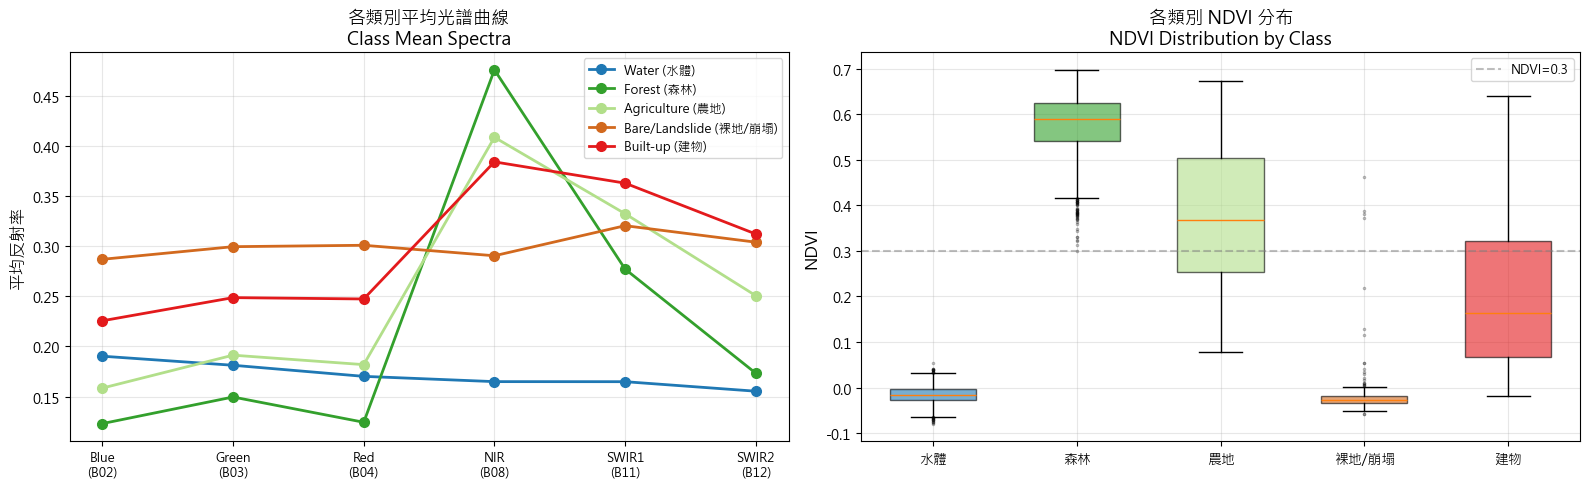


Saved:
output\roi_quality_diagnostics.png

圖表判讀：
  - 左圖：若兩條光譜曲線形狀接近，表示這兩類可能容易混淆。
  - 右圖：NDVI 一般應呈現水體最低、裸地較低、農地中等、森林較高。


In [14]:
# =============================================================================
# [S12b] ROI 智慧驗證 — 自動診斷訓練樣本品質
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# 0. Preparation
# -----------------------------------------------------------------------------
X_roi = X_roi.astype(np.float32)

BAND_NAMES = ["Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2"]

print("=" * 70)
print("ROI 智慧驗證開始")
print("=" * 70)

# =============================================================================
# 1. 樣本數量檢查
# =============================================================================

print("\n" + "=" * 70)
print("檢查 1／4：樣本數量")
print("=" * 70)

MIN_PIXELS = 30
REC_PIXELS = 100
GOOD_PIXELS = 500

qty_issues = []

sample_quality_records = []

for cls_id in range(N_CLASSES):

    count = int(np.sum(y_roi == cls_id))

    if count == 0:
        grade = "無樣本"
        status = "❌"
        qty_issues.append((cls_id, "missing"))
    elif count < MIN_PIXELS:
        grade = f"不足（最少 {MIN_PIXELS}）"
        status = "⚠️"
        qty_issues.append((cls_id, "low"))
    elif count < REC_PIXELS:
        grade = f"偏少（建議 {REC_PIXELS}+）"
        status = "🔶"
        qty_issues.append((cls_id, "marginal"))
    elif count < GOOD_PIXELS:
        grade = "合格"
        status = "✅"
    else:
        grade = "充足"
        status = "✅"

    print(
        f"  {CLASS_NAMES[cls_id]:>16s} ({CLASS_NAMES_ZH[cls_id]}): "
        f"{count:>6,} pixels  {status} {grade}"
    )

    sample_quality_records.append({
        "Class_ID": cls_id,
        "Class_Name": CLASS_NAMES[cls_id],
        "Class_Name_ZH": CLASS_NAMES_ZH[cls_id],
        "Pixel_Count": count,
        "Quantity_Status": grade
    })

sample_quality_df = pd.DataFrame(sample_quality_records)

# =============================================================================
# 2. 光譜合理性檢查
# =============================================================================

print("\n" + "=" * 70)
print("檢查 2／4：光譜合理性")
print("=" * 70)

spectral_issues = []

class_means = {}

for cls_id in range(N_CLASSES):

    mask_cls = (y_roi == cls_id)

    if np.sum(mask_cls) > 0:
        class_means[cls_id] = X_roi[mask_cls].mean(axis=0)
    else:
        class_means[cls_id] = None

# 波段索引：
# B02=0 Blue, B03=1 Green, B04=2 Red, B08=3 NIR, B11=4 SWIR1, B12=5 SWIR2

spectral_rules = {
    0: [
        ("NIR 應低（< 0.15）", lambda m: m[3] < 0.15,
         "水體通常強烈吸收近紅外光；若 NIR 偏高，可能混入陸地、淺灘或浪花。"),
        ("SWIR1 應低（< 0.15）", lambda m: m[4] < 0.15,
         "水體在 SWIR 波段通常反射率低；若偏高，可能選到河岸、沙洲或混合像素。"),
        ("Blue 通常高於 NIR", lambda m: m[0] > m[3],
         "若 Blue 未高於 NIR，可能 ROI 不是純水體。"),
    ],
    1: [
        ("NDVI 應高（> 0.4）", lambda m: (m[3] - m[2]) / (m[3] + m[2] + 1e-10) > 0.4,
         "健康森林通常具有高 NDVI；偏低可能混入裸地、道路或陰影。"),
        ("NIR 應高（> 0.20）", lambda m: m[3] > 0.20,
         "森林因葉片結構散射，NIR 通常較高。"),
        ("Red 應低於 NIR", lambda m: m[2] < m[3],
         "植生會吸收紅光並反射近紅外光。"),
    ],
    2: [
        ("NDVI 應為正（> 0.2）", lambda m: (m[3] - m[2]) / (m[3] + m[2] + 1e-10) > 0.2,
         "農地通常仍有植生覆蓋；若偏低，可能是裸露田、道路或建物。"),
        ("NIR 應適中（> 0.15）", lambda m: m[3] > 0.15,
         "農地 NIR 通常高於裸地與水體。"),
    ],
    3: [
        ("NDVI 應低（< 0.3）", lambda m: (m[3] - m[2]) / (m[3] + m[2] + 1e-10) < 0.3,
         "裸地／崩塌地植生少，NDVI 應偏低；若偏高可能混入植生恢復區。"),
        ("SWIR1 應可見（> 0.10）", lambda m: m[4] > 0.10,
         "裸露土壤、岩石、崩塌地通常在 SWIR 有一定反射率。"),
    ],
    4: [
        ("NDBI 應為正或接近 0", lambda m: (m[4] - m[3]) / (m[4] + m[3] + 1e-10) > -0.15,
         "建物與硬鋪面通常 SWIR 相對較高；若太負，可能混入植生。"),
        ("可見光平均反射率應適中（> 0.04）",
         lambda m: np.mean([m[0], m[1], m[2]]) > 0.04,
         "建物、道路或屋頂在可見光通常有一定反射率。"),
    ],
}

spectral_summary_records = []

for cls_id in range(N_CLASSES):

    m = class_means[cls_id]

    if m is None:
        print(f"\n  {CLASS_NAMES[cls_id]}：無樣本，無法檢查")
        continue

    ndvi = (m[3] - m[2]) / (m[3] + m[2] + 1e-10)
    ndbi = (m[4] - m[3]) / (m[4] + m[3] + 1e-10)

    print(f"\n  {CLASS_NAMES[cls_id]} ({CLASS_NAMES_ZH[cls_id]}):")
    print(
        f"    平均光譜: "
        f"Blue={m[0]:.4f}, Green={m[1]:.4f}, Red={m[2]:.4f}, "
        f"NIR={m[3]:.4f}, SWIR1={m[4]:.4f}, SWIR2={m[5]:.4f}"
    )
    print(f"    NDVI={ndvi:.3f}, NDBI={ndbi:.3f}")

    all_pass = True

    for rule_name, check_fn, advice in spectral_rules.get(cls_id, []):

        passed = check_fn(m)

        if passed:
            print(f"    ✅ {rule_name}")
        else:
            print(f"    ⚠️ {rule_name} — 未通過")
            print(f"       建議：{advice}")
            spectral_issues.append((cls_id, rule_name))
            all_pass = False

    if all_pass:
        print("    → 光譜特徵合理")

    spectral_summary_records.append({
        "Class_ID": cls_id,
        "Class_Name": CLASS_NAMES[cls_id],
        "Class_Name_ZH": CLASS_NAMES_ZH[cls_id],
        "Blue": m[0],
        "Green": m[1],
        "Red": m[2],
        "NIR": m[3],
        "SWIR1": m[4],
        "SWIR2": m[5],
        "NDVI": ndvi,
        "NDBI": ndbi
    })

spectral_summary_df = pd.DataFrame(spectral_summary_records)

# =============================================================================
# 3. 類別可分離性分析
# =============================================================================

print("\n" + "=" * 70)
print("檢查 3／4：類別可分離性")
print("=" * 70)

separability_issues = []

def bhattacharyya_distance(X1, X2):
    """
    使用簡化版 Bhattacharyya distance 計算類別分離度，
    並轉換為 Jeffries-Matusita distance。
    JM ∈ [0, 2]：>1.9 優秀，1.5–1.9 尚可，<1.5 易混淆
    """
    if len(X1) < 2 or len(X2) < 2:
        return 0.0

    m1, m2 = X1.mean(axis=0), X2.mean(axis=0)
    s1 = np.cov(X1.T) + np.eye(X1.shape[1]) * 1e-6
    s2 = np.cov(X2.T) + np.eye(X2.shape[1]) * 1e-6
    s_avg = (s1 + s2) / 2

    try:
        sign, logdet = np.linalg.slogdet(s_avg)
        sign1, logdet1 = np.linalg.slogdet(s1)
        sign2, logdet2 = np.linalg.slogdet(s2)

        if sign <= 0 or sign1 <= 0 or sign2 <= 0:
            return 0.0

        dm = m1 - m2

        term1 = 0.125 * dm @ np.linalg.solve(s_avg, dm)
        term2 = 0.5 * (logdet - 0.5 * (logdet1 + logdet2))

        bd = term1 + term2
        jm = 2 * (1 - np.exp(-bd))

        return min(jm, 2.0)

    except np.linalg.LinAlgError:
        return 0.0

jm_matrix = np.full((N_CLASSES, N_CLASSES), np.nan)

print("\nJeffries-Matusita distance matrix:")
print("JM > 1.9 = 容易區分；1.5–1.9 = 尚可；< 1.5 = 易混淆\n")

print(f"{'':20s}", end="")
for j in range(N_CLASSES):
    print(f"{CLASS_NAMES[j][:8]:>12s}", end="")
print()

for i in range(N_CLASSES):

    print(f"{CLASS_NAMES[i]:20s}", end="")

    for j in range(N_CLASSES):

        if i == j:
            print(f"{'---':>12s}", end="")
            jm_matrix[i, j] = np.nan

        elif j > i:
            Xi = X_roi[y_roi == i]
            Xj = X_roi[y_roi == j]

            if len(Xi) < 2 or len(Xj) < 2:
                print(f"{'N/A':>12s}", end="")
                jm_matrix[i, j] = np.nan
            else:
                jm = bhattacharyya_distance(Xi, Xj)
                jm_matrix[i, j] = jm
                jm_matrix[j, i] = jm

                if jm >= 1.9:
                    label = f"{jm:.2f} ✅"
                elif jm >= 1.5:
                    label = f"{jm:.2f} 🔶"
                else:
                    label = f"{jm:.2f} ⚠️"
                    separability_issues.append((CLASS_NAMES[i], CLASS_NAMES[j], jm))

                print(f"{label:>12s}", end="")
        else:
            print(f"{'':>12s}", end="")

    print()

jm_df = pd.DataFrame(
    jm_matrix,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)

# =============================================================================
# 4. ROI 空間分布檢查
# =============================================================================

print("\n" + "=" * 70)
print("檢查 4／4：ROI 空間分布")
print("=" * 70)

spatial_issues = []

for cls_id in range(N_CLASSES):

    mask_cls = (roi_raster == cls_id)

    if not np.any(mask_cls):
        print(f"  {CLASS_NAMES[cls_id]}：無 ROI")
        continue

    rows_cls, cols_cls = np.where(mask_cls)

    row_span = (rows_cls.max() - rows_cls.min()) / n_rows
    col_span = (cols_cls.max() - cols_cls.min()) / n_cols

    spread = max(row_span, col_span)

    n_poly = len(polygons_by_class[cls_id])

    if n_poly == 1 and spread < 0.05:
        status = "⚠️ 僅 1 個小區域，代表性不足"
        spatial_issues.append((cls_id, "single_small"))
    elif spread < 0.02:
        status = "⚠️ ROI 過度集中"
        spatial_issues.append((cls_id, "concentrated"))
    elif n_poly >= 2:
        status = f"✅ {n_poly} 個多邊形，分布合理"
    else:
        status = "🔶 建議增加更多分散 ROI"

    print(
        f"  {CLASS_NAMES[cls_id]:>16s}: "
        f"空間範圍 {spread * 100:.1f}% 影像寬度，"
        f"{n_poly} 個多邊形  {status}"
    )

# =============================================================================
# 5. 綜合評估
# =============================================================================

print("\n" + "=" * 70)
print("綜合評估報告")
print("=" * 70)

total_issues = (
    len(qty_issues)
    + len(spectral_issues)
    + len(separability_issues)
    + len(spatial_issues)
)

if total_issues == 0:
    print("\n🎉 ROI 品質良好，可以進入 Random Forest 模型訓練。")
elif total_issues <= 3:
    print(f"\n👍 ROI 大致良好，但仍有 {total_issues} 個小問題可改善。")
else:
    print(f"\n⚠️ ROI 發現 {total_issues} 個問題，建議改善後再訓練模型。")

suggestions = []

for cls_id, level in qty_issues:

    if level == "missing":
        suggestions.append(
            f"{CLASS_NAMES[cls_id]}：完全沒有樣本，請至少畫 2 個 ROI polygon。"
        )
    elif level == "low":
        suggestions.append(
            f"{CLASS_NAMES[cls_id]}：樣本數不足 {MIN_PIXELS}，請增加 ROI。"
        )
    elif level == "marginal":
        suggestions.append(
            f"{CLASS_NAMES[cls_id]}：樣本數偏少，建議增加到 {REC_PIXELS}+ pixels。"
        )

for cls_id, rule_name in spectral_issues:
    suggestions.append(
        f"{CLASS_NAMES[cls_id]}：光譜檢查「{rule_name}」未通過，請確認 ROI 是否畫在正確地物上。"
    )

for c1, c2, jm in separability_issues:
    suggestions.append(
        f"{c1} 與 {c2} 光譜相似（JM={jm:.2f}），後續分類可能混淆。"
    )

for cls_id, issue_type in spatial_issues:
    suggestions.append(
        f"{CLASS_NAMES[cls_id]}：ROI 空間分布較集中，建議在不同位置增加樣本。"
    )

if suggestions:
    print("\n改善建議：")
    for s in suggestions:
        print(f"  - {s}")

# =============================================================================
# 6. Save validation tables
# =============================================================================

sample_quality_df.to_csv(
    OUTPUT_DIR / "roi_quantity_check.csv",
    index=False,
    encoding="utf-8-sig"
)

spectral_summary_df.to_csv(
    OUTPUT_DIR / "roi_spectral_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

jm_df.to_csv(
    OUTPUT_DIR / "roi_jm_separability.csv",
    encoding="utf-8-sig"
)

print("\nSaved:")
print(OUTPUT_DIR / "roi_quantity_check.csv")
print(OUTPUT_DIR / "roi_spectral_summary.csv")
print(OUTPUT_DIR / "roi_jm_separability.csv")

# =============================================================================
# 7. Plot class mean spectra and NDVI distribution
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cls_colors = [
    "#1f78b4",
    "#33a02c",
    "#b2df8a",
    "#d2691e",
    "#e31a1c",
]

# -----------------------------------------------------------------------------
# Left: mean spectral curves
# -----------------------------------------------------------------------------
ax = axes[0]

for cls_id in range(N_CLASSES):

    m = class_means[cls_id]

    if m is not None:
        ax.plot(
            range(n_bands),
            m,
            "o-",
            color=cls_colors[cls_id],
            linewidth=2,
            markersize=7,
            label=f"{CLASS_NAMES[cls_id]} ({CLASS_NAMES_ZH[cls_id]})"
        )

ax.set_xticks(range(n_bands))
ax.set_xticklabels(
    [f"{BAND_NAMES[i]}\n({BANDS[i]})" for i in range(n_bands)],
    fontsize=9
)

ax.set_ylabel("平均反射率", fontsize=12)
ax.set_title("各類別平均光譜曲線\nClass Mean Spectra", fontsize=13)
ax.legend(fontsize=9, loc="upper right")
ax.grid(True, alpha=0.3)

# -----------------------------------------------------------------------------
# Right: NDVI boxplot
# -----------------------------------------------------------------------------
ax2 = axes[1]

ndvi_by_class = []
labels_bp = []

for cls_id in range(N_CLASSES):

    mask_cls = (y_roi == cls_id)

    if np.sum(mask_cls) > 0:
        cls_data = X_roi[mask_cls]

        ndvi_cls = (
            (cls_data[:, 3] - cls_data[:, 2])
            / (cls_data[:, 3] + cls_data[:, 2] + 1e-10)
        )

        ndvi_by_class.append(ndvi_cls)
        labels_bp.append(f"{CLASS_NAMES_ZH[cls_id]}")
    else:
        ndvi_by_class.append([0])
        labels_bp.append(f"{CLASS_NAMES_ZH[cls_id]}*")

bp = ax2.boxplot(
    ndvi_by_class,
    labels=labels_bp,
    patch_artist=True,
    widths=0.6,
    showfliers=True,
    flierprops=dict(marker=".", markersize=3, alpha=0.3)
)

for patch, color in zip(bp["boxes"], cls_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax2.set_ylabel("NDVI", fontsize=12)
ax2.set_title("各類別 NDVI 分布\nNDVI Distribution by Class", fontsize=13)
ax2.axhline(
    y=0.3,
    color="gray",
    linestyle="--",
    alpha=0.5,
    label="NDVI=0.3"
)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "roi_quality_diagnostics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved:")
print(OUTPUT_DIR / "roi_quality_diagnostics.png")

print("\n圖表判讀：")
print("  - 左圖：若兩條光譜曲線形狀接近，表示這兩類可能容易混淆。")
print("  - 右圖：NDVI 一般應呈現水體最低、裸地較低、農地中等、森林較高。")

## Task 2B. Random Forest Supervised Classification

本步驟使用前一步由 KMZ ROI 解析出的訓練樣本進行 Random Forest 監督式分類。  
訓練資料包含五類土地覆蓋：水體、森林、農地、裸地／崩塌與建物。

資料會先以 80/20 分割為訓練集與測試集，並使用 stratify 保持各類別比例一致。  
Random Forest 設定為 200 棵樹，並啟用 OOB score，以利後續 Task 3 進行內部精度評估。

由於本研究區水體與森林樣本數較多，而農地、裸地與建物樣本相對較少，因此模型結果需搭配 confusion matrix 與 feature importance 進一步檢查。

In [15]:
# =============================================================================
# Task 2B. Assemble Training Data + Train Random Forest
# =============================================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# 1. Assemble training data from KMZ ROI samples
# -----------------------------------------------------------------------------
# X_roi, y_roi 已由 [S12] KMZ ROI 解析產生
X_train = X_roi.copy()
y_train = y_roi.copy()

class_names = CLASS_NAMES
class_names_zh = CLASS_NAMES_ZH

print("=" * 70)
print("Task 2B. Random Forest Training")
print("=" * 70)

print("Training data shape:", X_train.shape)
print("Label shape:", y_train.shape)

print("\nTraining sample count by class:")
sample_records = []

for class_id, class_name in enumerate(class_names):
    count = int(np.sum(y_train == class_id))
    pct = count / len(y_train) * 100

    print(
        f"  Class {class_id}: {class_name:>16s} / {class_names_zh[class_id]} "
        f"= {count:>6,} pixels ({pct:5.1f}%)"
    )

    sample_records.append({
        "Class_ID": class_id,
        "Class_Name": class_name,
        "Class_Name_ZH": class_names_zh[class_id],
        "Pixel_Count": count,
        "Percentage": round(pct, 2)
    })

training_sample_df = pd.DataFrame(sample_records)
display(training_sample_df)

# -----------------------------------------------------------------------------
# 2. 80/20 train-test split
# -----------------------------------------------------------------------------
X_tr, X_te, y_tr, y_te = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("\nTrain / Test split:")
print("X_tr:", X_tr.shape)
print("X_te:", X_te.shape)

split_records = []

for class_id, class_name in enumerate(class_names):
    n_train = int(np.sum(y_tr == class_id))
    n_test = int(np.sum(y_te == class_id))

    print(
        f"  Class {class_id}: {class_name:>16s} / {class_names_zh[class_id]} "
        f"Train={n_train:>5,}, Test={n_test:>4,}"
    )

    split_records.append({
        "Class_ID": class_id,
        "Class_Name": class_name,
        "Class_Name_ZH": class_names_zh[class_id],
        "Train_Count": n_train,
        "Test_Count": n_test
    })

split_df = pd.DataFrame(split_records)
display(split_df)

# -----------------------------------------------------------------------------
# 3. Train Random Forest
# -----------------------------------------------------------------------------
# oob_score=True 是為了 Task 3 後續 OOB validation 使用
# class_weight="balanced" 可降低水體、森林樣本較多造成的類別不平衡影響
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    oob_score=True,
    class_weight="balanced",
    max_features="sqrt"
)

rf.fit(X_tr, y_tr)

# -----------------------------------------------------------------------------
# 4. Accuracy summary
# -----------------------------------------------------------------------------
train_acc = rf.score(X_tr, y_tr)
test_acc = rf.score(X_te, y_te)
oob_acc = rf.oob_score_

print("\nRandom Forest training completed.")
print(f"Training accuracy: {train_acc:.3f}")
print(f"Test accuracy:     {test_acc:.3f}")
print(f"OOB accuracy:      {oob_acc:.3f}")

rf_accuracy_df = pd.DataFrame({
    "Metric": ["Training Accuracy", "Test Accuracy", "OOB Accuracy"],
    "Value": [train_acc, test_acc, oob_acc]
})

display(rf_accuracy_df)

# -----------------------------------------------------------------------------
# 5. Save tables
# -----------------------------------------------------------------------------
training_sample_df.to_csv(
    OUTPUT_DIR / "rf_training_sample_distribution.csv",
    index=False,
    encoding="utf-8-sig"
)

split_df.to_csv(
    OUTPUT_DIR / "rf_train_test_split_counts.csv",
    index=False,
    encoding="utf-8-sig"
)

rf_accuracy_df.to_csv(
    OUTPUT_DIR / "rf_accuracy_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved:")
print(OUTPUT_DIR / "rf_training_sample_distribution.csv")
print(OUTPUT_DIR / "rf_train_test_split_counts.csv")
print(OUTPUT_DIR / "rf_accuracy_summary.csv")

Task 2B. Random Forest Training
Training data shape: (7007, 6)
Label shape: (7007,)

Training sample count by class:
  Class 0:            Water / 水體 =  3,477 pixels ( 49.6%)
  Class 1:           Forest / 森林 =  2,812 pixels ( 40.1%)
  Class 2:      Agriculture / 農地 =    255 pixels (  3.6%)
  Class 3:   Bare/Landslide / 裸地/崩塌 =    285 pixels (  4.1%)
  Class 4:         Built-up / 建物 =    178 pixels (  2.5%)


,Class_ID,Class_Name,Class_Name_ZH,Pixel_Count,Percentage
0,0,Water,水體,3477,49.62
1,1,Forest,森林,2812,40.13
2,2,Agriculture,農地,255,3.64
3,3,Bare/Landslide,裸地/崩塌,285,4.07
4,4,Built-up,建物,178,2.54



Train / Test split:
X_tr: (5605, 6)
X_te: (1402, 6)
  Class 0:            Water / 水體 Train=2,781, Test= 696
  Class 1:           Forest / 森林 Train=2,249, Test= 563
  Class 2:      Agriculture / 農地 Train=  204, Test=  51
  Class 3:   Bare/Landslide / 裸地/崩塌 Train=  228, Test=  57
  Class 4:         Built-up / 建物 Train=  143, Test=  35


,Class_ID,Class_Name,Class_Name_ZH,Train_Count,Test_Count
0,0,Water,水體,2781,696
1,1,Forest,森林,2249,563
2,2,Agriculture,農地,204,51
3,3,Bare/Landslide,裸地/崩塌,228,57
4,4,Built-up,建物,143,35



Random Forest training completed.
Training accuracy: 1.000
Test accuracy:     0.989
OOB accuracy:      0.983


,Metric,Value
0,Training Accuracy,1.000000
1,Test Accuracy,0.988588
2,OOB Accuracy,0.983408



Saved:
output\rf_training_sample_distribution.csv
output\rf_train_test_split_counts.csv
output\rf_accuracy_summary.csv


### Updated Random Forest Training Result Analysis

本研究於第二次 ROI 修正後，增加了建物（Built-up）訓練樣本，使建物類別總樣本數由原先約 131 pixels 提升至 178 pixels，其中訓練集包含 143 pixels、測試集包含 35 pixels。此修正有助於提升模型對少數類別的學習能力，降低建物類別在分類過程中被森林或裸地混淆的風險。

在 train/test split 結果中：
- Water：Train 2781 / Test 696
- Forest：Train 2249 / Test 563
- Agriculture：Train 204 / Test 51
- Bare/Landslide：Train 228 / Test 57
- Built-up：Train 143 / Test 35

雖然建物類別樣本數仍低於水體與森林，但已較前一版本更具代表性。

模型精度結果如下：
- Training accuracy = 1.000
- Test accuracy = 0.989
- OOB accuracy = 0.983

Training accuracy 仍達 1.000，表示 Random Forest 已完整擬合訓練資料；然而 Test accuracy 與 OOB accuracy 仍維持在約 0.98 以上，且彼此差距不大，顯示模型在未參與訓練的測試樣本上仍具有良好的泛化能力，未出現明顯過度擬合。

與前一版本相比，OOB accuracy 由約 0.989 略降至 0.983，這可能代表新增的建物 ROI 引入了更多光譜變異性，例如：
- 屋頂材質差異
- 道路與建物混合像素
- 聚落陰影
- 建物與裸地的 SWIR 相似性

雖然整體精度略微下降，但這通常代表模型開始學習更接近真實世界的光譜複雜性，而非只擬合少量高一致性的建物樣本，因此此變化屬合理現象。

此外，需要注意：
- Agriculture、Bare/Landslide 與 Built-up 仍屬少數類別，其測試樣本數相對有限，因此 precision 與 recall 指標可能仍較敏感。
- 本研究目前的 test accuracy 仍屬「同源 ROI 驗證」，因此後續仍需透過 confusion matrix 與 SWCB landslide inventory 進行外部驗證，以確認模型對真實崩塌地與混合地物的辨識能力。

整體而言，更新後的 ROI 樣本配置較前一版本更平衡，並能提供更具代表性的監督式分類結果，可進一步用於全影像土地覆蓋分類與後續災害分析。

Task 2C. Classify Entire Image
Prediction completed.
Predicted valid pixels: 1593880
class_map shape: (852, 2041)


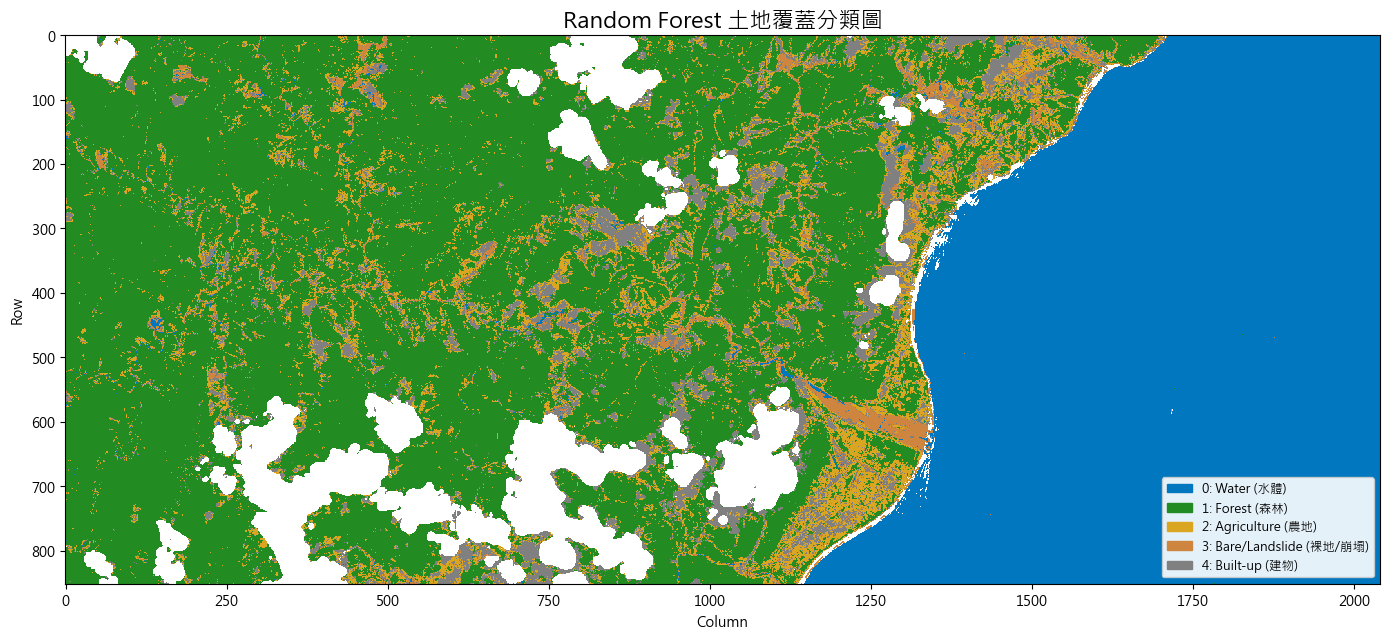

Saved:
output\rf_classification.png

Class area statistics:
  Class 0:            Water / 水體 =  560,135 pixels,  22405.4 ha,  35.1%
  Class 1:           Forest / 森林 =  788,709 pixels,  31548.4 ha,  49.5%
  Class 2:      Agriculture / 農地 =  119,934 pixels,   4797.4 ha,   7.5%
  Class 3:   Bare/Landslide / 裸地/崩塌 =   25,161 pixels,   1006.4 ha,   1.6%
  Class 4:         Built-up / 建物 =   99,941 pixels,   3997.6 ha,   6.3%


,Class_ID,Class_Name,Class_Name_ZH,Pixels,Area_ha,Percentage
0,0,Water,水體,560135,22405.40,35.14
1,1,Forest,森林,788709,31548.36,49.48
2,2,Agriculture,農地,119934,4797.36,7.52
3,3,Bare/Landslide,裸地/崩塌,25161,1006.44,1.58
4,4,Built-up,建物,99941,3997.64,6.27


Saved:
output\rf_class_area_stats.csv


In [16]:
# =============================================================================
# Task 2C. Classify Entire Image
# =============================================================================

from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("=" * 70)
print("Task 2C. Classify Entire Image")
print("=" * 70)

# -----------------------------------------------------------------------------
# 1. Predict all valid pixels
# -----------------------------------------------------------------------------
y_pred_all = rf.predict(X_valid)

print("Prediction completed.")
print("Predicted valid pixels:", len(y_pred_all))

# -----------------------------------------------------------------------------
# 2. Rebuild as 2D classification map
# -----------------------------------------------------------------------------
class_map = np.full(h * w, np.nan)
class_map[valid] = y_pred_all
class_map = class_map.reshape(h, w)

print("class_map shape:", class_map.shape)

# -----------------------------------------------------------------------------
# 3. Visualization
# -----------------------------------------------------------------------------
class_colors = [
    "#0077BE",  # Water
    "#228B22",  # Forest
    "#DAA520",  # Agriculture
    "#CD853F",  # Bare/Landslide
    "#808080",  # Built-up
]

class_cmap = ListedColormap(class_colors)
class_norm = BoundaryNorm(np.arange(-0.5, N_CLASSES + 0.5, 1), class_cmap.N)

fig, ax = plt.subplots(figsize=(14, 8))

im = ax.imshow(
    class_map,
    cmap=class_cmap,
    norm=class_norm,
    interpolation="nearest"
)

ax.set_title("Random Forest 土地覆蓋分類圖", fontsize=16)
ax.set_xlabel("Column")
ax.set_ylabel("Row")

legend_patches = [
    mpatches.Patch(
        color=class_colors[i],
        label=f"{i}: {class_names[i]} ({class_names_zh[i]})"
    )
    for i in range(N_CLASSES)
]

ax.legend(
    handles=legend_patches,
    loc="lower right",
    fontsize=9,
    framealpha=0.9
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "rf_classification.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(OUTPUT_DIR / "rf_classification.png")

# -----------------------------------------------------------------------------
# 4. Quick class area statistics for Task 2 discussion
# -----------------------------------------------------------------------------
pixel_area_m2 = 20 * 20
valid_class_pixels = np.sum(~np.isnan(class_map))

area_records = []

print("\nClass area statistics:")

for class_id, class_name in enumerate(class_names):
    n_pixels = int(np.sum(class_map == class_id))
    area_ha = n_pixels * pixel_area_m2 / 10000
    pct = n_pixels / valid_class_pixels * 100

    print(
        f"  Class {class_id}: {class_name:>16s} / {class_names_zh[class_id]} "
        f"= {n_pixels:>8,} pixels, {area_ha:>8.1f} ha, {pct:>5.1f}%"
    )

    area_records.append({
        "Class_ID": class_id,
        "Class_Name": class_name,
        "Class_Name_ZH": class_names_zh[class_id],
        "Pixels": n_pixels,
        "Area_ha": round(area_ha, 2),
        "Percentage": round(pct, 2)
    })

rf_area_df = pd.DataFrame(area_records)
display(rf_area_df)

rf_area_df.to_csv(
    OUTPUT_DIR / "rf_class_area_stats.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved:")
print(OUTPUT_DIR / "rf_class_area_stats.csv")

### Random Forest Classification Map Analysis

Random Forest 全影像分類結果顯示，研究區土地覆蓋主要以森林與海域為主，符合太魯閣—秀林地區同時包含高山森林與太平洋海岸的地理特性。

分類統計結果如下：

| 類別 | 面積比例 |
|---|---|
| Water（水體） | 35.1% |
| Forest（森林） | 49.5% |
| Agriculture（農地） | 7.5% |
| Bare/Landslide（裸地／崩塌） | 1.6% |
| Built-up（建物） | 6.3% |

其中：
- 森林（49.5%）為研究區最大類別，主要分布於山區地形。
- 水體（35.1%）主要來自東側太平洋海域，因此比例相對較高。
- 農地（7.5%）與建物（6.3%）主要集中於沿海平原與聚落區。
- 裸地／崩塌（1.6%）面積相對較小，但在河道、沖積扇與山區裸露區仍可辨識出連續分布。

從空間分布來看：
- 山區大部分被分類為森林，顯示 NIR 波段對植生辨識具有良好效果。
- 海域被穩定分類為水體，顯示模型對低 NIR / SWIR 反射率的水體特徵辨識良好。
- 沿海聚落與道路周圍出現較多建物與農地類別，符合真實地景。
- 河道與沖積區可見裸地／崩塌類別分布，顯示 SWIR 波段對裸露土壤與崩塌地具有一定辨識能力。

不過，分類圖中仍可觀察到部分潛在混淆現象：
- 山區陰影可能被誤判為建物或裸地。
- 農地與建物在聚落周圍呈現交錯分布，可能與混合像素（mixed pixels）有關。
- 部分裸露河床與建物屋頂在 SWIR 波段具有相似反射特徵，因此可能造成局部誤分類。

此外，本研究區包含大量海域，因此水體比例偏高；若僅分析陸域範圍，森林比例將進一步提高，而水體比例則會下降。

整體而言，Random Forest 相較於 K-means 非監督式分類，已能更穩定地對應到具名土地覆蓋類別，並產生較符合實際地景分布的分類結果，可進一步用於後續崩塌地分析與 SWCB inventory 驗證。

Feature importance:


,Band,Band_Label,Importance
3,B08,B08 NIR,0.231331
5,B12,B12 SWIR2,0.200154
4,B11,B11 SWIR1,0.171238
0,B02,B02 Blue,0.152429
2,B04,B04 Red,0.132988
1,B03,B03 Green,0.111859


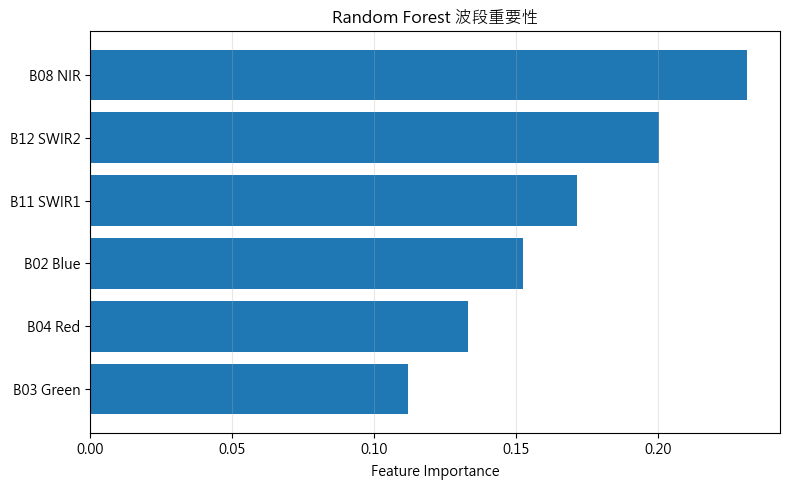

Saved:
output\rf_feature_importance.csv
output\rf_feature_importance.png


In [17]:
# =============================================================================
# Task 2D. Feature Importance — Which Bands Matter Most?
# =============================================================================

import matplotlib.pyplot as plt
import pandas as pd

importance = rf.feature_importances_

band_names = ["B02", "B03", "B04", "B08", "B11", "B12"]
band_labels = [
    "B02 Blue",
    "B03 Green",
    "B04 Red",
    "B08 NIR",
    "B11 SWIR1",
    "B12 SWIR2"
]

importance_df = pd.DataFrame({
    "Band": band_names,
    "Band_Label": band_labels,
    "Importance": importance
}).sort_values("Importance", ascending=False)

print("Feature importance:")
display(importance_df)

importance_df.to_csv(
    OUTPUT_DIR / "rf_feature_importance.csv",
    index=False,
    encoding="utf-8-sig"
)

# -----------------------------------------------------------------------------
# Plot feature importance
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    importance_df["Band_Label"],
    importance_df["Importance"]
)

ax.set_xlabel("Feature Importance")
ax.set_title("Random Forest 波段重要性")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "rf_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(OUTPUT_DIR / "rf_feature_importance.csv")
print(OUTPUT_DIR / "rf_feature_importance.png")

### Feature Importance Analysis

Random Forest feature importance 結果顯示，不同 Sentinel-2 波段對土地覆蓋分類的重要性存在明顯差異。

本研究的波段重要性排序如下：

| Rank | Band | Importance |
|---|---|---|
| 1 | B08 NIR | 0.231 |
| 2 | B12 SWIR2 | 0.200 |
| 3 | B11 SWIR1 | 0.171 |
| 4 | B02 Blue | 0.152 |
| 5 | B04 Red | 0.133 |
| 6 | B03 Green | 0.112 |

其中，B08（NIR）為最重要波段，顯示模型最依賴植生與非植生之間的近紅外反射差異進行分類。森林與農地通常具有較高 NIR 反射率，而水體則會強烈吸收近紅外光，因此 NIR 對於區分森林、水體與裸地特別重要。

第二與第三重要的波段為：
- B12（SWIR2）
- B11（SWIR1）

SWIR 波段對土壤含水量、裸露岩石、建物與崩塌地非常敏感，因此在：
- 裸地／崩塌地
- 建物
- 河道裸露區

等類別辨識中具有重要作用。  
這也說明 Random Forest 並非只利用植生資訊，而是同時結合近紅外與短波紅外特徵來辨識不同土地覆蓋類型。

此外，B02（Blue）重要性高於 Red 與 Green，也具有一定合理性。研究區包含大量海域與沿海混濁水體，而 Blue 波段對水體散射與海岸邊界較敏感，因此在水體辨識中仍具有貢獻。

相較之下：
- Green（B03）
- Red（B04）

的重要性較低，可能是因為：
- 可見光波段容易受到陰影與地形影響
- 不同地物在可見光範圍的光譜差異較小
- 植生分類主要已由 NIR 提供較強判別能力

整體而言，本研究結果顯示：
- NIR 是區分植生與非植生的核心波段
- SWIR1 / SWIR2 是辨識裸地、崩塌與建物的重要波段
- Random Forest 成功整合多波段資訊，而非依賴單一波段進行分類

此結果也與遙測理論一致，顯示模型具有合理的物理意義與光譜解釋能力。

C:\Users\User\AppData\Local\Temp\ipykernel_18220\3105744744.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  k_cmap = plt.cm.get_cmap("Set1", 5)


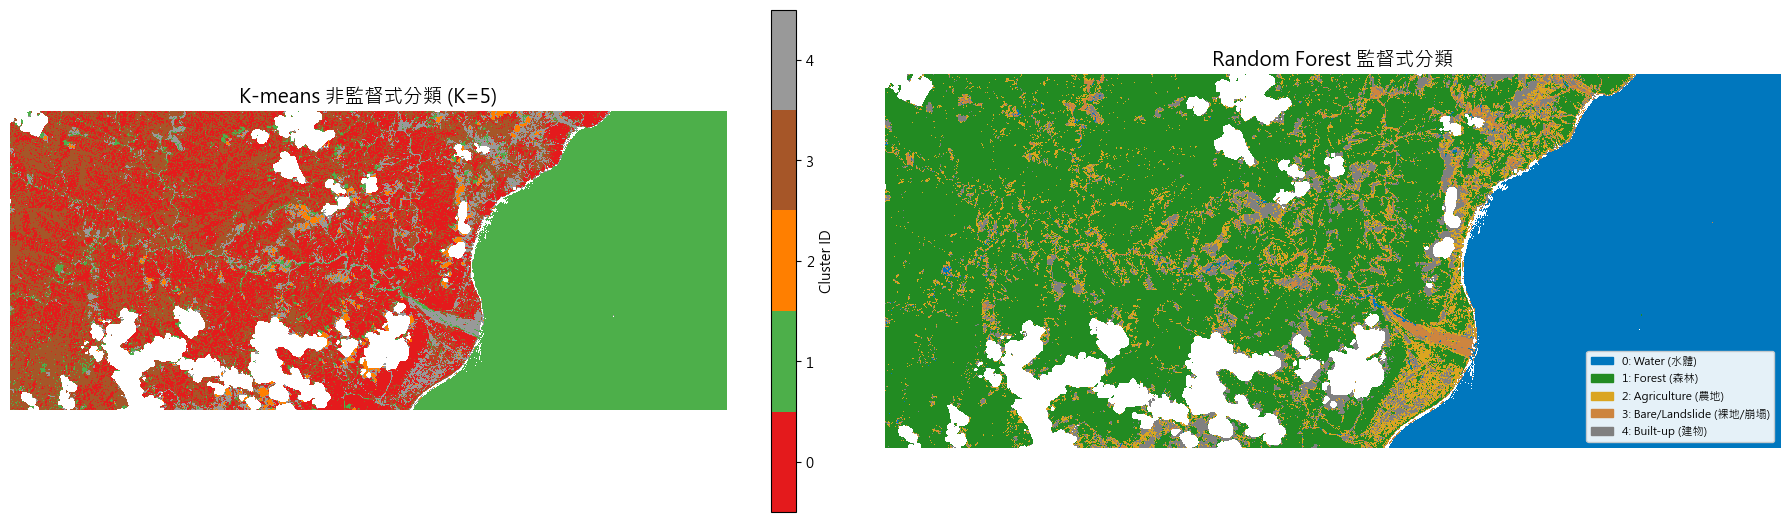

Saved:
output\kmeans_vs_rf_comparison.png


In [18]:
# =============================================================================
# Task 2E. K-means vs Random Forest Side-by-side Comparison
# =============================================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# -----------------------------------------------------------------------------
# Left: K-means classification
# -----------------------------------------------------------------------------
k_cmap = plt.cm.get_cmap("Set1", 5)

im0 = axes[0].imshow(
    label_map,
    cmap=k_cmap,
    vmin=-0.5,
    vmax=4.5,
    interpolation="nearest"
)

axes[0].set_title("K-means 非監督式分類 (K=5)", fontsize=14)
axes[0].axis("off")

cbar0 = plt.colorbar(
    im0,
    ax=axes[0],
    ticks=range(5),
    shrink=0.75
)
cbar0.set_label("Cluster ID")

# -----------------------------------------------------------------------------
# Right: Random Forest classification
# -----------------------------------------------------------------------------
im1 = axes[1].imshow(
    class_map,
    cmap=class_cmap,
    norm=class_norm,
    interpolation="nearest"
)

axes[1].set_title("Random Forest 監督式分類", fontsize=14)
axes[1].axis("off")

axes[1].legend(
    handles=legend_patches,
    loc="lower right",
    fontsize=8,
    framealpha=0.9
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "kmeans_vs_rf_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(OUTPUT_DIR / "kmeans_vs_rf_comparison.png")

### K-means vs Random Forest Comparison

K-means 與 Random Forest 的分類結果呈現明顯差異。  
K-means 是非監督式分類，僅根據像素光譜相似性進行分群，因此 cluster ID 本身沒有固定地物意義，必須透過平均光譜曲線與人工判讀解釋。其優點是能快速探索影像中的自然光譜分群，但缺點是容易受到山區陰影、混合像素與水體比例影響。

Random Forest 則使用人工 ROI 訓練樣本進行監督式分類，因此輸出結果可直接對應到水體、森林、農地、裸地／崩塌與建物等具名類別。相較於 K-means，Random Forest 的分類圖較容易支援後續面積統計、崩塌分析與災害應用。不過，其結果也高度依賴訓練樣本品質，因此仍需透過 Task 3 的 confusion matrix 與 SWCB 外部資料進行精度驗證。

## Task 3. Accuracy Assessment & Independent Validation

本任務評估 Random Forest 分類結果的可靠性，分為：

- Part A：使用 train/test split 進行內部精度驗證（internal validation）
- Part B：使用 SWCB 崩塌地 inventory 進行外部驗證（external validation）

Part A 主要透過 confusion matrix、classification report 與 OOB accuracy 評估模型在不同土地覆蓋類別上的分類表現。

本步驟重點包括：
- confusion matrix
- precision / recall / F1-score
- macro avg vs weighted avg
- support（每類別測試像素數）
- OOB accuracy vs test accuracy 比較

Task 3A. Internal Accuracy Assessment
Prediction completed.
Test samples: 1402

Confusion Matrix:
[[696   0   0   0   0]
 [  0 562   1   0   0]
 [  0   1  48   0   2]
 [  0   0   4  52   1]
 [  0   0   6   1  28]]


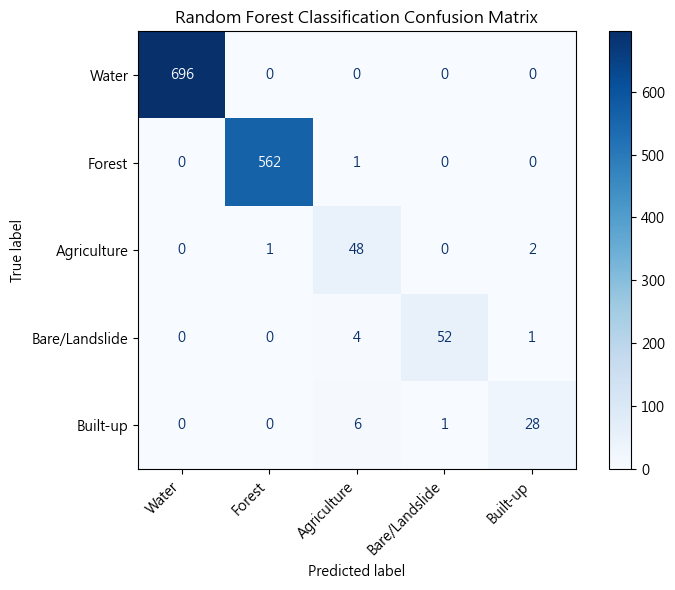

Saved:
output\confusion_matrix.png

=== Classification Report ===

                precision    recall  f1-score   support

         Water     1.0000    1.0000    1.0000       696
        Forest     0.9982    0.9982    0.9982       563
   Agriculture     0.8136    0.9412    0.8727        51
Bare/Landslide     0.9811    0.9123    0.9455        57
      Built-up     0.9032    0.8000    0.8485        35

      accuracy                         0.9886      1402
     macro avg     0.9392    0.9303    0.9330      1402
  weighted avg     0.9893    0.9886    0.9887      1402



,precision,recall,f1-score,support
Water,1.000000,1.000000,1.000000,696.000000
Forest,0.998224,0.998224,0.998224,563.000000
Agriculture,0.813559,0.941176,0.872727,51.000000
Bare/Landslide,0.981132,0.912281,0.945455,57.000000
Built-up,0.903226,0.800000,0.848485,35.000000
accuracy,0.988588,0.988588,0.988588,0.988588
macro avg,0.939228,0.930336,0.932978,1402.000000
weighted avg,0.989322,0.988588,0.988657,1402.000000


Saved:
output\classification_report.csv
output\classification_report.txt

=== OOB vs Test Accuracy ===
OOB Accuracy:  0.9834
Test Accuracy: 0.9886
Absolute Gap:  0.0052
✅ OOB 與 Test accuracy 接近，模型穩定性良好

=== Macro vs Weighted Avg Analysis ===
Macro avg F1:    0.9330
Weighted avg F1: 0.9887
Gap:              0.0557
⚠️ Gap > 0.03，代表少數類別可能被大類別稀釋

=== Support Reliability Check ===
✅            Water: support =   696
✅           Forest: support =   563
✅      Agriculture: support =    51
✅   Bare/Landslide: support =    57
✅         Built-up: support =    35


,Class_Name,Support,Status
0,Water,696.0,Acceptable
1,Forest,563.0,Acceptable
2,Agriculture,51.0,Acceptable
3,Bare/Landslide,57.0,Acceptable
4,Built-up,35.0,Acceptable


Saved:
output\support_reliability_check.csv


,Metric,Value
0,Training Accuracy,1.000000
1,Test Accuracy,0.988588
2,OOB Accuracy,0.983408
3,Macro F1,0.932978
4,Weighted F1,0.988657
5,Weighted-Macro Gap,0.055679


Saved:
output\accuracy_assessment_summary.csv


In [19]:
# =============================================================================
# Task 3A. Internal Accuracy Assessment
# =============================================================================

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("Task 3A. Internal Accuracy Assessment")
print("=" * 70)

# -----------------------------------------------------------------------------
# 1. Predict test set
# -----------------------------------------------------------------------------
y_pred_test = rf.predict(X_te)

print("Prediction completed.")
print("Test samples:", len(y_te))

# -----------------------------------------------------------------------------
# 2. Confusion Matrix
# -----------------------------------------------------------------------------
cm = confusion_matrix(y_te, y_pred_test)

print("\nConfusion Matrix:")
print(cm)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=True
)

ax.set_title("Random Forest Classification Confusion Matrix")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(OUTPUT_DIR / "confusion_matrix.png")

# -----------------------------------------------------------------------------
# 3. Classification Report
# -----------------------------------------------------------------------------
print("\n=== Classification Report ===\n")

report_text = classification_report(
    y_te,
    y_pred_test,
    target_names=class_names,
    digits=4
)

print(report_text)

# dictionary version
report_dict = classification_report(
    y_te,
    y_pred_test,
    target_names=class_names,
    digits=4,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).T

display(report_df)

# save
report_df.to_csv(
    OUTPUT_DIR / "classification_report.csv",
    encoding="utf-8-sig"
)

with open(
    OUTPUT_DIR / "classification_report.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(report_text)

print("Saved:")
print(OUTPUT_DIR / "classification_report.csv")
print(OUTPUT_DIR / "classification_report.txt")

# -----------------------------------------------------------------------------
# 4. OOB vs Test Accuracy
# -----------------------------------------------------------------------------
oob_acc = rf.oob_score_
test_acc = rf.score(X_te, y_te)

print("\n=== OOB vs Test Accuracy ===")

print(f"OOB Accuracy:  {oob_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

gap = abs(oob_acc - test_acc)

print(f"Absolute Gap:  {gap:.4f}")

if gap < 0.02:
    print("✅ OOB 與 Test accuracy 接近，模型穩定性良好")
else:
    print("⚠️ OOB 與 Test accuracy 差異較大，可能存在 overfitting")

# -----------------------------------------------------------------------------
# 5. Macro vs Weighted Avg Analysis
# -----------------------------------------------------------------------------
macro_f1 = report_dict["macro avg"]["f1-score"]
weighted_f1 = report_dict["weighted avg"]["f1-score"]

f1_gap = weighted_f1 - macro_f1

print("\n=== Macro vs Weighted Avg Analysis ===")

print(f"Macro avg F1:    {macro_f1:.4f}")
print(f"Weighted avg F1: {weighted_f1:.4f}")
print(f"Gap:              {f1_gap:.4f}")

if f1_gap > 0.03:
    print("⚠️ Gap > 0.03，代表少數類別可能被大類別稀釋")
else:
    print("✅ Macro 與 Weighted avg 差距不大")

# -----------------------------------------------------------------------------
# 6. Support Reliability Check
# -----------------------------------------------------------------------------
print("\n=== Support Reliability Check ===")

support_records = []

for cls_name in class_names:

    support = report_dict[cls_name]["support"]

    if support < 30:
        status = "Potentially Unreliable"
        icon = "⚠️"
    else:
        status = "Acceptable"
        icon = "✅"

    print(
        f"{icon} {cls_name:>16s}: "
        f"support = {support:>5.0f}"
    )

    support_records.append({
        "Class_Name": cls_name,
        "Support": support,
        "Status": status
    })

support_df = pd.DataFrame(support_records)

display(support_df)

support_df.to_csv(
    OUTPUT_DIR / "support_reliability_check.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved:")
print(OUTPUT_DIR / "support_reliability_check.csv")

# -----------------------------------------------------------------------------
# 7. Summary Metrics Table
# -----------------------------------------------------------------------------
summary_df = pd.DataFrame({
    "Metric": [
        "Training Accuracy",
        "Test Accuracy",
        "OOB Accuracy",
        "Macro F1",
        "Weighted F1",
        "Weighted-Macro Gap"
    ],
    "Value": [
        train_acc,
        test_acc,
        oob_acc,
        macro_f1,
        weighted_f1,
        f1_gap
    ]
})

display(summary_df)

summary_df.to_csv(
    OUTPUT_DIR / "accuracy_assessment_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved:")
print(OUTPUT_DIR / "accuracy_assessment_summary.csv")

### Task 3A. Internal Accuracy Assessment Analysis

Random Forest 模型整體分類表現良好：
- Test accuracy = 0.9886
- OOB accuracy = 0.9834

兩者差距僅約 0.005，表示模型穩定性良好，未出現明顯 overfitting。

從 confusion matrix 可見：
- Water 與 Forest 幾乎完全正確分類，顯示 NIR 波段對植生與水體辨識效果非常好。
- Bare/Landslide 的 F1-score 為 0.946，表示模型對裸地／崩塌地具有良好辨識能力。
- Built-up 的 recall 較低（0.800），代表部分建物仍被誤判為 Agriculture 或 Bare/Landslide，可能與混合像素及光譜相似性有關。

此外：
- Macro F1 = 0.9330
- Weighted F1 = 0.9887
- Gap = 0.0557 (> 0.03)

顯示整體高精度主要受到 Water 與 Forest 等大型類別影響，而少數類別（Agriculture、Built-up）表現相對較弱。

整體而言，Random Forest 已能有效辨識主要土地覆蓋類別，但建物與部分裸地仍存在局部混淆，後續需透過 SWCB landslide inventory 進行外部驗證。

## Task 3B. Independent Validation with SWCB Landslide Inventory

本步驟使用農業部水土保持署（SWCB）提供的震後崩塌地 inventory 作為外部驗證資料（independent reference data）。

與前面的 train/test split 不同，SWCB 崩塌地 polygons 並未參與 Random Forest 訓練，因此可作為真正的 external validation，用來評估模型對實際崩塌地的空間辨識能力。

本步驟將：
1. 讀取 SWCB KML 崩塌 polygons
2. 裁切至研究區範圍
3. Rasterize 成與 classification map 相同解析度
4. 與 RF landslide class 進行 pixel-level overlap analysis

In [20]:
# =============================================================================
# Task 3B-1. Load SWCB Landslide Inventory
# =============================================================================

import geopandas as gpd
import xml.etree.ElementTree as ET

from shapely.geometry import Polygon, box
import pandas as pd

print("=" * 70)
print("Task 3B-1. Load SWCB Landslide Inventory")
print("=" * 70)

# -----------------------------------------------------------------------------
# 1. Define KML path
# -----------------------------------------------------------------------------
kml_path = DATA_DIR / "20240802新生崩塌地.kml"

print("KML path:")
print(kml_path)

# -----------------------------------------------------------------------------
# 2. Parse KML
# -----------------------------------------------------------------------------
tree = ET.parse(kml_path)

ns = {
    'kml': 'http://www.opengis.net/kml/2.2'
}

polygons = []

for pm in tree.getroot().findall('.//kml:Placemark', ns):

    coords_el = pm.find('.//kml:coordinates', ns)

    if coords_el is not None:

        coords = []

        for pt in coords_el.text.strip().split():

            lon, lat, *_ = pt.split(',')

            coords.append((
                float(lon),
                float(lat)
            ))

        if len(coords) >= 3:

            polygons.append(
                Polygon(coords)
            )

print(f"\nTotal polygons in KML: {len(polygons)}")

# -----------------------------------------------------------------------------
# 3. Create GeoDataFrame
# -----------------------------------------------------------------------------
gdf_swcb = gpd.GeoDataFrame(
    geometry=polygons,
    crs='EPSG:4326'
)

print("\nSWCB GeoDataFrame:")
display(gdf_swcb.head())

print("\nCRS:")
print(gdf_swcb.crs)

# -----------------------------------------------------------------------------
# 4. Clip to study area
# -----------------------------------------------------------------------------
study_box = box(*TAROKO_BBOX)

gdf_clipped = gdf_swcb[
    gdf_swcb.intersects(study_box)
].copy()

print(f"\nSWCB polygons inside study area: {len(gdf_clipped)}")

# -----------------------------------------------------------------------------
# 5. Quick geometry statistics
# -----------------------------------------------------------------------------
gdf_clipped_proj = gdf_clipped.to_crs("EPSG:32651")

gdf_clipped_proj["Area_m2"] = gdf_clipped_proj.area

print("\nPolygon area statistics:")

print(
    gdf_clipped_proj["Area_m2"].describe()
)

# -----------------------------------------------------------------------------
# 6. Save clipped inventory
# -----------------------------------------------------------------------------
gdf_clipped.to_file(
    OUTPUT_DIR / "swcb_clipped_inventory.geojson",
    driver="GeoJSON"
)

print("\nSaved:")
print(OUTPUT_DIR / "swcb_clipped_inventory.geojson")

Task 3B-1. Load SWCB Landslide Inventory
KML path:
data\20240802新生崩塌地.kml

Total polygons in KML: 1335

SWCB GeoDataFrame:


,geometry
0,"POLYGON ((120.65432 22.91308, 120.65432 22.912..."
1,"POLYGON ((120.65838 22.91458, 120.65829 22.914..."
2,"POLYGON ((120.65991 22.91446, 120.66004 22.914..."
3,"POLYGON ((120.64685 22.87677, 120.64685 22.876..."
4,"POLYGON ((120.64706 22.87641, 120.64705 22.876..."



CRS:
EPSG:4326

SWCB polygons inside study area: 207

Polygon area statistics:
count       207.000000
mean       4436.499846
std       14290.934425
min           0.002333
25%         899.998235
50%        1600.002056
75%        3000.000207
max      178111.996575
Name: Area_m2, dtype: float64

Saved:
output\swcb_clipped_inventory.geojson


## Task 3B-2. Rasterize SWCB Landslide Inventory

本步驟將 SWCB 崩塌 polygons rasterize 成與 Random Forest classification map 相同的空間解析度與 grid。

轉換後：
- SWCB landslide pixel = 1
- non-landslide pixel = 0

如此即可與 RF landslide class 進行 pixel-level overlap analysis。

Task 3B-2. Rasterize SWCB Inventory
Raster shape:
h = 852, w = 2041

Transform:
| 0.00, 0.00, 121.40|
| 0.00,-0.00, 24.25|
| 0.00, 0.00, 1.00|

Rasterization completed.

SWCB landslide statistics:
SWCB landslide pixels: 2,403
Total pixels:          1,738,932
Percentage:            0.138%


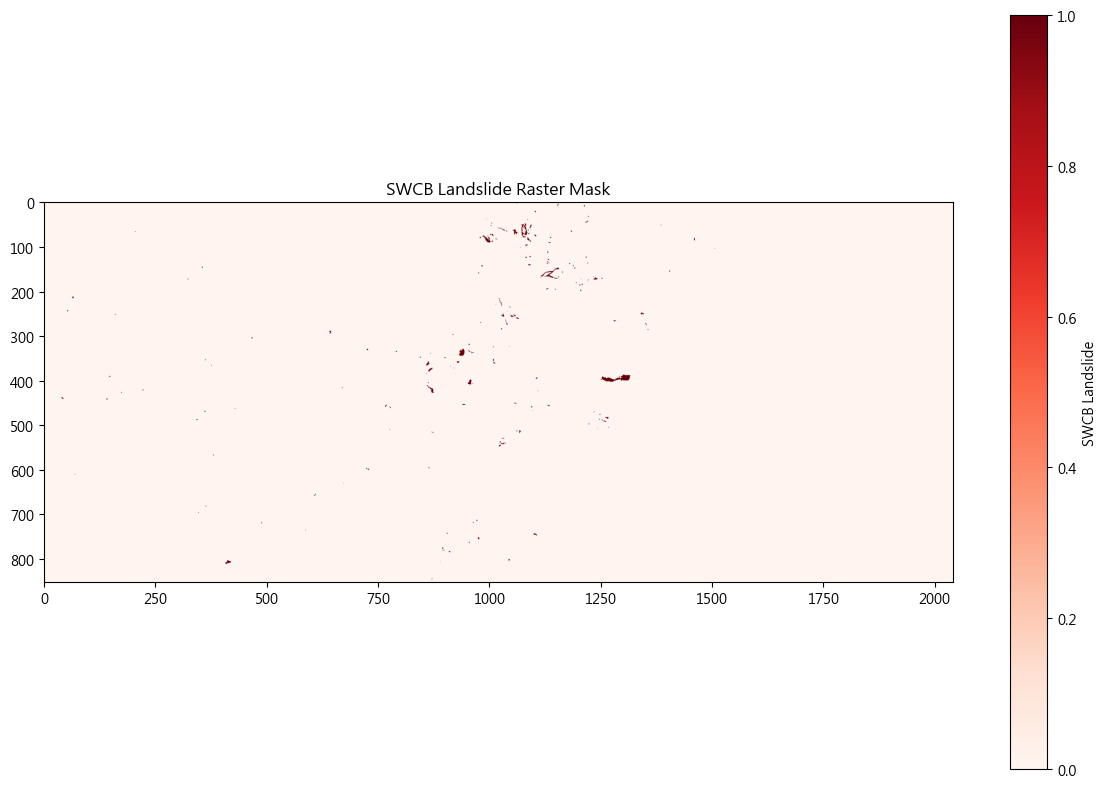


Saved:
output\swcb_raster_mask.png


,Metric,Value
0,SWCB Landslide Pixels,2.403000e+03
1,Total Pixels,1.738932e+06
2,Percentage,1.381883e-01


Saved:
output\swcb_mask_statistics.csv


In [21]:
# =============================================================================
# Task 3B-2. Rasterize SWCB Landslide Inventory
# =============================================================================

from rasterio.features import rasterize
from rasterio.transform import from_bounds

print("=" * 70)
print("Task 3B-2. Rasterize SWCB Inventory")
print("=" * 70)

# -----------------------------------------------------------------------------
# 1. Build raster transform
# -----------------------------------------------------------------------------
transform = from_bounds(
    *TAROKO_BBOX,
    w,
    h
)

print("Raster shape:")
print(f"h = {h}, w = {w}")

print("\nTransform:")
print(transform)

# -----------------------------------------------------------------------------
# 2. Rasterize polygons
# -----------------------------------------------------------------------------
swcb_mask = rasterize(
    [(geom, 1) for geom in gdf_clipped.geometry],

    out_shape=(h, w),

    transform=transform,

    fill=0,

    dtype='uint8'
)

print("\nRasterization completed.")

# -----------------------------------------------------------------------------
# 3. Pixel statistics
# -----------------------------------------------------------------------------
swcb_pixels = swcb_mask.sum()

total_pixels = h * w

percent = swcb_pixels / total_pixels * 100

print("\nSWCB landslide statistics:")

print(f"SWCB landslide pixels: {swcb_pixels:,}")

print(f"Total pixels:          {total_pixels:,}")

print(f"Percentage:            {percent:.3f}%")

# -----------------------------------------------------------------------------
# 4. Visualization
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8))

im = ax.imshow(
    swcb_mask,
    cmap="Reds"
)

ax.set_title(
    "SWCB Landslide Raster Mask"
)

plt.colorbar(
    im,
    ax=ax,
    label="SWCB Landslide"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "swcb_raster_mask.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved:")
print(OUTPUT_DIR / "swcb_raster_mask.png")

# -----------------------------------------------------------------------------
# 5. Save statistics table
# -----------------------------------------------------------------------------
swcb_stats_df = pd.DataFrame({
    "Metric": [
        "SWCB Landslide Pixels",
        "Total Pixels",
        "Percentage"
    ],
    "Value": [
        swcb_pixels,
        total_pixels,
        percent
    ]
})

display(swcb_stats_df)

swcb_stats_df.to_csv(
    OUTPUT_DIR / "swcb_mask_statistics.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved:")
print(OUTPUT_DIR / "swcb_mask_statistics.csv")

## Task 3B-3. Spatial Overlap Analysis

本步驟比較：
- Random Forest 預測的 Bare/Landslide 類別
- SWCB 官方崩塌 inventory

透過 pixel-level overlap analysis 計算：
- Recall（偵測率）
- Precision（正確率）
- IoU（Intersection over Union）

並建立 TP / FN / FP overlay map，用來分析模型漏判與誤判的位置分布。

Task 3B-3. RF vs SWCB Overlap Analysis
RF landslide pixels:
25,161

Pixel Counts:
TP (correct detection): 89
FN (missed landslide):  2,314
FP (false alarm):       25,072

Spatial Overlap Metrics:
Recall (Detection Rate): 0.0370
Precision:               0.0035
IoU (Jaccard Index):     0.0032


,Metric,Value
0,Recall,0.037037
1,Precision,0.003537
2,IoU,0.003239



Saved:
output\spatial_overlap_metrics.csv


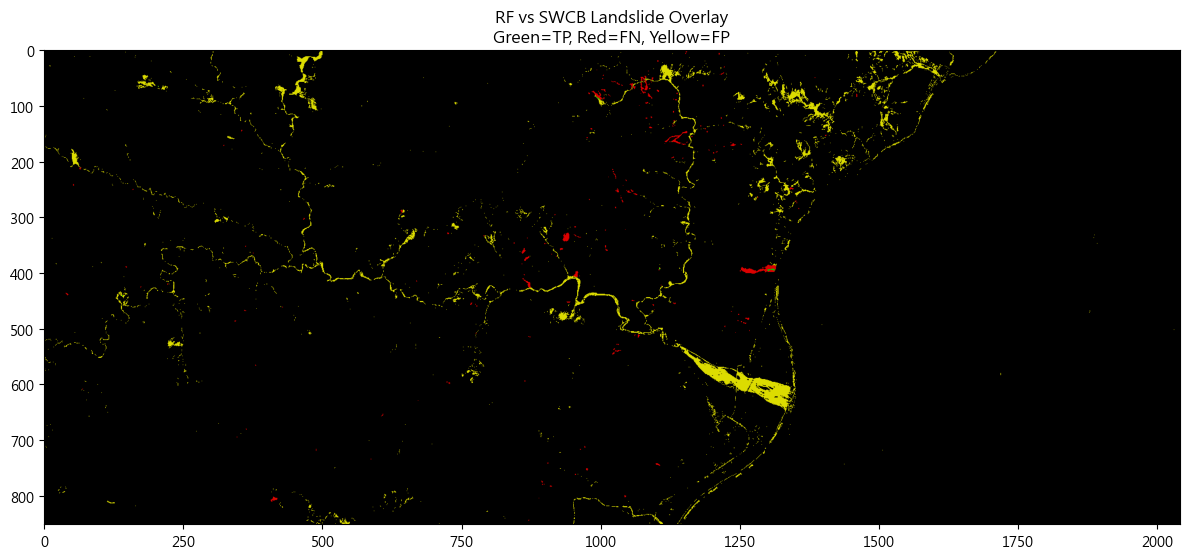

Saved:
output\swcb_overlay.png


In [22]:
# =============================================================================
# Task 3B-3. RF vs SWCB Spatial Overlap Analysis
# =============================================================================

print("=" * 70)
print("Task 3B-3. RF vs SWCB Overlap Analysis")
print("=" * 70)

# -----------------------------------------------------------------------------
# 1. Extract RF landslide class
# -----------------------------------------------------------------------------
rf_landslide = (class_map == 3).astype(np.uint8)

print("RF landslide pixels:")
print(f"{rf_landslide.sum():,}")

# -----------------------------------------------------------------------------
# 2. Compute overlap
# -----------------------------------------------------------------------------
tp = (
    (rf_landslide == 1) &
    (swcb_mask == 1)
)

fn = (
    (rf_landslide == 0) &
    (swcb_mask == 1)
)

fp = (
    (rf_landslide == 1) &
    (swcb_mask == 0)
)

# -----------------------------------------------------------------------------
# 3. Pixel counts
# -----------------------------------------------------------------------------
tp_count = tp.sum()
fn_count = fn.sum()
fp_count = fp.sum()

print("\nPixel Counts:")

print(f"TP (correct detection): {tp_count:,}")
print(f"FN (missed landslide):  {fn_count:,}")
print(f"FP (false alarm):       {fp_count:,}")

# -----------------------------------------------------------------------------
# 4. Metrics
# -----------------------------------------------------------------------------
intersection = tp_count

union = (
    (rf_landslide == 1) |
    (swcb_mask == 1)
).sum()

recall = (
    intersection / swcb_mask.sum()
    if swcb_mask.sum() > 0 else 0
)

precision = (
    intersection / rf_landslide.sum()
    if rf_landslide.sum() > 0 else 0
)

iou = (
    intersection / union
    if union > 0 else 0
)

print("\nSpatial Overlap Metrics:")

print(f"Recall (Detection Rate): {recall:.4f}")

print(f"Precision:               {precision:.4f}")

print(f"IoU (Jaccard Index):     {iou:.4f}")

# -----------------------------------------------------------------------------
# 5. Metrics table
# -----------------------------------------------------------------------------
metrics_df = pd.DataFrame({
    "Metric": [
        "Recall",
        "Precision",
        "IoU"
    ],
    "Value": [
        recall,
        precision,
        iou
    ]
})

display(metrics_df)

metrics_df.to_csv(
    OUTPUT_DIR / "spatial_overlap_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved:")
print(OUTPUT_DIR / "spatial_overlap_metrics.csv")

# -----------------------------------------------------------------------------
# 6. Create overlay map
# -----------------------------------------------------------------------------
overlay = np.zeros((h, w, 3), dtype=np.uint8)

# TP = green
overlay[tp] = [0, 200, 0]

# FN = red
overlay[fn] = [220, 0, 0]

# FP = yellow
overlay[fp] = [220, 220, 0]

# -----------------------------------------------------------------------------
# 7. Visualization
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 10))

ax.imshow(overlay)

ax.set_title(
    "RF vs SWCB Landslide Overlay\n"
    "Green=TP, Red=FN, Yellow=FP"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "swcb_overlay.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(OUTPUT_DIR / "swcb_overlay.png")

### External Validation Discussion

與 SWCB 官方崩塌 inventory 的外部驗證結果顯示，Random Forest 分類結果與官方崩塌地之間的空間重疊程度偏低。雖然模型在內部驗證中具有非常高的精度（Test accuracy = 0.9886），但外部驗證結果較差（Recall = 0.037、Precision = 0.0035、IoU = 0.0032），顯示 Random Forest 模型主要辨識到的是「裸露地表」，而不是真正的震後新生崩塌地。

造成 overlap 不佳的原因有幾個。首先，Sentinel-2 影像日期（2024-08-27）與 SWCB inventory 日期（2024-08-02）存在時間差，期間可能已發生植生恢復、沖刷或崩塌邊界改變。其次，Sentinel-2 的空間解析度為 20 m，而 SWCB 使用更高解析度影像進行人工判釋，因此許多小型崩塌地難以被 Sentinel-2 偵測。此外，本研究的 Bare/Landslide 類別同時包含河床、裸土、沖積區與道路等裸露地表，因此容易與真正崩塌地產生光譜混淆，造成大量 FP（false positives）。

從 overlay map 可觀察到，大部分 FN（漏判崩塌）集中於山區的小型或破碎化崩塌地，這些區域可能受到植生覆蓋、地形陰影或 mixed pixels 影響，導致模型難以辨識。相對地，FP 則大量分布於河道與沖積扇附近，顯示裸露河床與新生崩塌在 Sentinel-2 光譜空間中具有高度相似性。

整體而言，本研究結果顯示 internal validation 與 external validation 之間存在明顯差異。雖然 Random Forest 能有效學習人工 ROI 樣本，但在真實世界崩塌辨識上仍受到解析度、時間差與類別定義差異影響，這也是遙測災害分類中常見的限制。

## Task 4-1. Land Cover Area Statistics

本步驟統計 Random Forest 分類結果中各土地覆蓋類別的面積與比例。

統計結果將作為後續 AI disaster briefing 的輸入資料，用來描述研究區內不同土地覆蓋類型的空間分布情形。

Task 4-1. Land Cover Area Statistics
Pixel area: 400 m²

Valid classified pixels: 1,593,880


,Class_Name,Pixels,Area_ha,Percentage
0,Water,560135.0,22405.4,35.14
1,Forest,788709.0,31548.4,49.48
2,Agriculture,119934.0,4797.4,7.52
3,Bare/Landslide,25161.0,1006.4,1.58
4,Built-up,99941.0,3997.6,6.27



Saved:
output\task4_area_statistics.csv


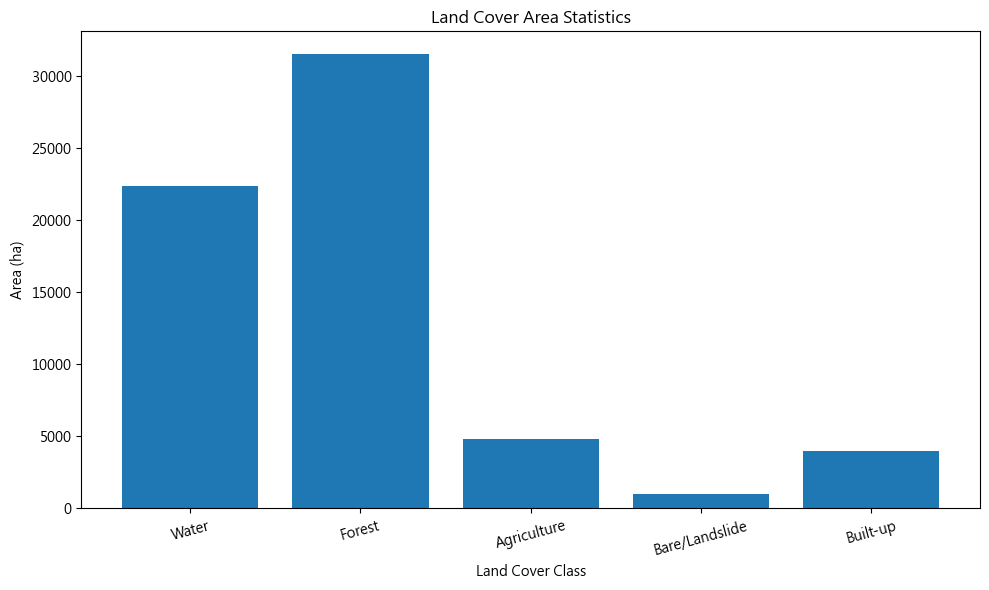

Saved:
output\task4_area_bar_chart.png


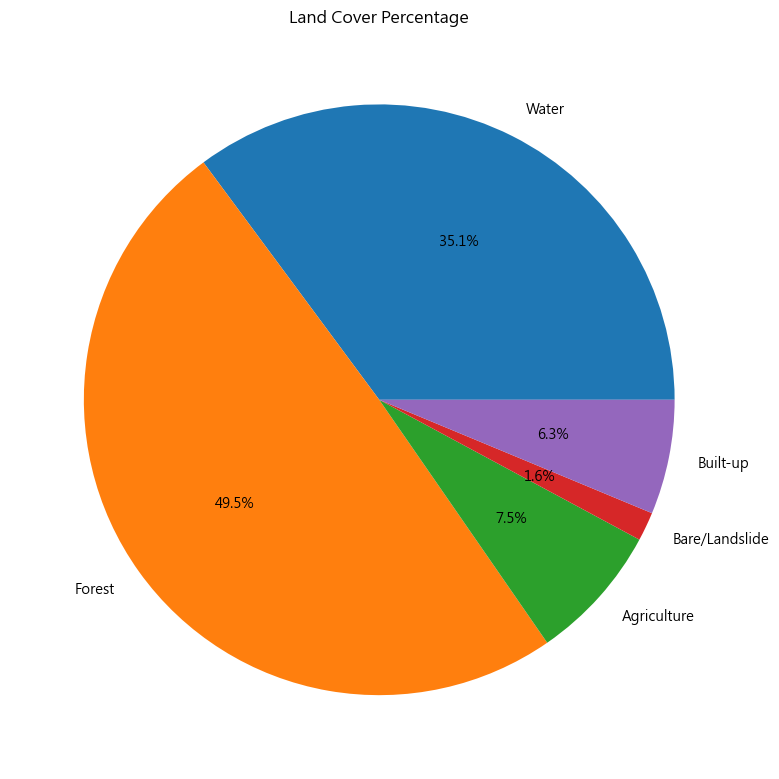

Saved:
output\task4_area_pie_chart.png


In [23]:
# =============================================================================
# Task 4-1. Land Cover Area Statistics
# =============================================================================

print("=" * 70)
print("Task 4-1. Land Cover Area Statistics")
print("=" * 70)

# -----------------------------------------------------------------------------
# 1. Pixel area
# -----------------------------------------------------------------------------
pixel_area_m2 = 20 * 20

print(f"Pixel area: {pixel_area_m2} m²")

# -----------------------------------------------------------------------------
# 2. Compute statistics
# -----------------------------------------------------------------------------
class_stats = {}

valid_pixels = np.sum(~np.isnan(class_map))

print(f"\nValid classified pixels: {valid_pixels:,}")

for i, name in enumerate(class_names):

    n_pixels = np.sum(class_map == i)

    area_ha = n_pixels * pixel_area_m2 / 10000

    percentage = (
        n_pixels / valid_pixels * 100
    )

    class_stats[name] = {

        'pixels': int(n_pixels),

        'area_ha': round(area_ha, 1),

        'percentage': round(percentage, 2)
    }

# -----------------------------------------------------------------------------
# 3. Convert to DataFrame
# -----------------------------------------------------------------------------
stats_df = pd.DataFrame(class_stats).T

stats_df = stats_df.reset_index()

stats_df.columns = [
    'Class_Name',
    'Pixels',
    'Area_ha',
    'Percentage'
]

display(stats_df)

# -----------------------------------------------------------------------------
# 4. Save CSV
# -----------------------------------------------------------------------------
stats_df.to_csv(
    OUTPUT_DIR / "task4_area_statistics.csv",
    index=False,
    encoding='utf-8-sig'
)

print("\nSaved:")
print(OUTPUT_DIR / "task4_area_statistics.csv")

# -----------------------------------------------------------------------------
# 5. Bar chart
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    stats_df["Class_Name"],
    stats_df["Area_ha"]
)

ax.set_title(
    "Land Cover Area Statistics"
)

ax.set_ylabel(
    "Area (ha)"
)

ax.set_xlabel(
    "Land Cover Class"
)

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "task4_area_bar_chart.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Saved:")
print(OUTPUT_DIR / "task4_area_bar_chart.png")

# -----------------------------------------------------------------------------
# 6. Pie chart
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 8))

ax.pie(
    stats_df["Percentage"],
    labels=stats_df["Class_Name"],
    autopct='%1.1f%%'
)

ax.set_title(
    "Land Cover Percentage"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "task4_area_pie_chart.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Saved:")
print(OUTPUT_DIR / "task4_area_pie_chart.png")

## Task 4-2. AI-ready Disaster Summary

本步驟將前面分類與驗證結果整理為 AI-ready summary，作為後續 LLM disaster briefing 的輸入資料。

摘要內容包含：
- 土地覆蓋面積比例
- 崩塌地面積
- Random Forest accuracy
- SWCB overlap metrics
- External validation 結果

In [24]:
# =============================================================================
# Task 4B. Build LLM Prompt
# =============================================================================

import os
from dotenv import load_dotenv
import google.generativeai as genai

# -----------------------------------------------------------------------------
# 1. Load API key
# -----------------------------------------------------------------------------
load_dotenv()

GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

if GEMINI_API_KEY is None:

    raise ValueError(
        "找不到 GEMINI_API_KEY，請確認 .env 已設定"
    )

genai.configure(api_key=GEMINI_API_KEY)

# -----------------------------------------------------------------------------
# 2. Set Gemini model
# -----------------------------------------------------------------------------
# 舊版 SDK 最穩定的 model
model = genai.GenerativeModel("gemini-pro")

# -----------------------------------------------------------------------------
# 3. Prepare metrics
# -----------------------------------------------------------------------------
overall_accuracy = rf.score(X_te, y_te)

swcb_iou = iou
swcb_recall = recall
swcb_precision = precision

# -----------------------------------------------------------------------------
# 4. Build prompt
# -----------------------------------------------------------------------------
prompt = f"""
你是花蓮縣災害應變中心的 GIS 分析師。

請根據以下災後土地覆蓋分類結果，
撰寫一份「災後土地覆蓋分析報告」。

字數：
300–500 字。

研究區：
秀林鄉 / 太魯閣周邊
（含蘇花公路沿線及近海區域）

災害事件：
2024 年 4 月 3 日花蓮地震（M7.4）

分類方法：
Random Forest（6 波段 Sentinel-2，5 類別）

Internal validation:
- Overall accuracy: {overall_accuracy:.1%}
- OOB accuracy: {rf.oob_score_:.1%}

SWCB external validation:
- Recall: {swcb_recall:.4f}
- Precision: {swcb_precision:.4f}
- IoU: {swcb_iou:.4f}

各類別面積統計：
{stats_df[['Class_Name', 'Area_ha', 'Percentage']].to_string(index=False)}

報告需包含：

1. 災後土地覆蓋概況
2. 崩塌 / 裸地面積估計與空間分布
3. 與 SWCB 官方判釋結果之比對與不確定性
4. 此分類圖如何支援後續避難所評估或路網分析

請特別注意：

- 不要過度宣稱模型已精準偵測崩塌地
- 必須說明 internal validation 高，但 external validation 很低
- 必須說明此成果較適合作為初步篩選與輔助判讀
- 不應視為最終官方崩塌判釋成果
"""

print(prompt)


你是花蓮縣災害應變中心的 GIS 分析師。

請根據以下災後土地覆蓋分類結果，
撰寫一份「災後土地覆蓋分析報告」。

字數：
300–500 字。

研究區：
秀林鄉 / 太魯閣周邊
（含蘇花公路沿線及近海區域）

災害事件：
2024 年 4 月 3 日花蓮地震（M7.4）

分類方法：
Random Forest（6 波段 Sentinel-2，5 類別）

Internal validation:
- Overall accuracy: 98.9%
- OOB accuracy: 98.3%

SWCB external validation:
- Recall: 0.0370
- Precision: 0.0035
- IoU: 0.0032

各類別面積統計：
    Class_Name  Area_ha  Percentage
         Water  22405.4       35.14
        Forest  31548.4       49.48
   Agriculture   4797.4        7.52
Bare/Landslide   1006.4        1.58
      Built-up   3997.6        6.27

報告需包含：

1. 災後土地覆蓋概況
2. 崩塌 / 裸地面積估計與空間分布
3. 與 SWCB 官方判釋結果之比對與不確定性
4. 此分類圖如何支援後續避難所評估或路網分析

請特別注意：

- 不要過度宣稱模型已精準偵測崩塌地
- 必須說明 internal validation 高，但 external validation 很低
- 必須說明此成果較適合作為初步篩選與輔助判讀
- 不應視為最終官方崩塌判釋成果



C:\Users\User\AppData\Local\Temp\ipykernel_18220\3908444790.py:7: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [25]:
# =============================================================================
# Check available Gemini models
# =============================================================================

import os
from dotenv import load_dotenv
import google.generativeai as genai

load_dotenv()
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
genai.configure(api_key=GEMINI_API_KEY)

for m in genai.list_models():
    if "generateContent" in m.supported_generation_methods:
        print(m.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gemini-2.5-computer-use-preview-10-2025
models/deep-research-max-preview-04-2026
models/deep-research-prev

In [27]:
# =============================================================================
# Task 4B-2. Generate LLM Report
# =============================================================================

model = genai.GenerativeModel("models/gemini-2.5-flash")

response = model.generate_content(prompt)

llm_report = response.text

print("=" * 70)
print("LLM-generated Report")
print("=" * 70)
print(llm_report)

with open(OUTPUT_DIR / "llm_generated_report.txt", "w", encoding="utf-8") as f:
    f.write(llm_report)

with open(OUTPUT_DIR / "llm_generated_report.md", "w", encoding="utf-8") as f:
    f.write("# LLM-generated Disaster Report\n\n")
    f.write(llm_report)

print("\nSaved:")
print(OUTPUT_DIR / "llm_generated_report.txt")
print(OUTPUT_DIR / "llm_generated_report.md")

LLM-generated Report
**花蓮縣災害應變中心**

**2024年4月3日花蓮地震 秀林鄉災後土地覆蓋分析報告 (初步)**

**GIS分析師：[您的姓名]**

**報告日期：2024年4月X日**

---

**一、 前言與研究目的**

為評估2024年4月3日M7.4花蓮地震對秀林鄉及太魯閣周邊地區（含蘇花公路沿線及近海區域）土地覆蓋的影響，本中心利用Sentinel-2衛星影像與Random Forest分類方法，生成災後土地覆蓋分類圖。本報告旨在提供初步的土地覆蓋概況、崩塌/裸地估計，並說明其應用潛力與限制。

**二、 災後土地覆蓋概況**

根據Sentinel-2影像分類結果，研究區內以自然地貌為主，其中：
*   **森林** 面積約為31,548.4公頃，佔總面積的49.48%，仍為主要覆蓋類型。
*   **水體**（含海洋與河流）面積約為22,405.4公頃，佔35.14%。
*   **農業區** 面積約4,797.4公頃，佔7.52%。
*   **建物區** 面積約3,997.6公頃，佔6.27%。
*   **裸地/崩塌** 面積約1,006.4公頃，佔總面積的1.58%。

**三、 崩塌/裸地面積估計與空間分布**

初步判釋結果顯示，研究區內裸地/崩塌類別面積估計為1,006.4公頃。這些區域主要分佈於高山坡地、峽谷地形，特別是太魯閣國家公園內部山區及蘇花公路沿線的陡峭邊坡。這些新增的裸露地表，是地震活動可能誘發落石、坍方或淺層崩塌的初步跡象。

**四、 與水保局（SWCB）官方判釋比對與不確定性**

本Random Forest模型內部驗證結果顯示，其整體準確度（Overall Accuracy）達98.9%，袋外準確度（OOB Accuracy）達98.3%，表明模型本身對訓練資料的分類能力良好。

然而，與水土保持局（SWCB）的官方崩塌判釋結果進行外部驗證時，模型的召回率（Recall 0.0370）、精確度（Precision 0.0035）及IoU（0.0032）皆極低。這明確指出本模型在精確偵測與SWCB官方定義及空間範圍一致的「崩塌地」方面存在顯著挑戰。可能原因包括Sentinel-2影像中解析度（10-20公尺）的限制、雲霧或地形陰影遮蔽、以及模型對崩塌光譜特徵的廣泛識別與官方對崩

## Task 4C. LLM Output Evaluation

LLM 報告中引用的面積統計數值大致正確，與本研究的分類結果一致。例如森林面積約為 31,548.4 公頃、水體面積約為 22,405.4 公頃，以及 Bare/Landslide 面積約為 1,006.4 公頃，皆與 Random Forest 分類統計結果相符，因此未發現明顯的 AI hallucination 或虛構數值問題。

此外，LLM 對模型不確定性的描述也具有合理性。報告中正確指出，雖然 internal validation accuracy 很高（Overall accuracy = 98.9%），但與 SWCB 官方崩塌 inventory 的空間重疊程度非常低（IoU = 0.0032）。因此，該分類圖較適合作為災後初步篩選與輔助判讀工具，而非最終官方崩塌判釋成果，此說明是合理且符合本研究結果的。

不過，報告仍有幾點可以進一步補充。首先，Sentinel-2 的空間解析度為 20 m，容易在狹窄河谷或小型崩塌地產生 mixed-pixel effects，降低崩塌辨識能力。其次，Sentinel-2 影像日期（2024-08-27）與 SWCB inventory 日期（2024-08-02）存在時間差，期間可能發生植生恢復或泥砂重新分布，進一步降低 overlap。最後，本研究的 Bare/Landslide 類別實際上包含河床、沖積扇與裸露道路等地物，因此容易與真正崩塌地產生光譜混淆，造成大量 false positives。

## ARIA v8.0 upgrade reflection

在 Week 8–10 的 ARIA 工作流程中，災害判釋主要依賴 NDVI、NDWI 與 SAR backscatter 等 threshold-based 方法進行分類。此方法具有流程簡單、易於解釋與快速實作等優點，但其分類效果高度依賴人工設定閾值，且容易受到地形陰影、雲層、混合像素與地物光譜重疊等因素影響，因此在複雜地形環境中常出現誤判。

本週 ARIA v8.0 則進一步導入 machine learning classifier 的概念，從固定 threshold 方法升級為 supervised classification workflow。研究中使用 Random Forest 結合多波段 Sentinel-2 特徵與 ROI 訓練樣本進行土地覆蓋分類，能同時考慮多維光譜資訊，而非僅依賴單一指標閾值，因此對不同地物類型具有較佳辨識能力。此外，本週也加入 confusion matrix、Macro/Weighted F1、OOB score 與 SWCB external validation 等完整驗證流程，使模型評估不再僅依賴單一 accuracy 指標。

然而，本研究亦發現即使 internal accuracy 很高，外部驗證與 SWCB inventory 的 overlap 仍偏低，顯示 machine learning classifier 並不代表結果一定可靠。外部驗證的重要性因此更加凸顯。整體而言，ARIA v8.0 的核心進展，在於從「人工 threshold 判讀」進一步發展為「結合 classifier、validation 與 AI interpretation 的完整災害分析流程」。